In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats, optimize
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

plt.rcParams['grid.alpha'] = 0.3

UNDERLYING = 'VELVETFRUIT_EXTRACT'
STRIKES    = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
OPT_SYMS   = [f'VEV_{k}' for k in STRIKES]
ALL_PRODS  = [UNDERLYING] + OPT_SYMS
POS_LIMIT  = 100

In [10]:
# ── Load all price data ───────────────────────────────────────────────────────
price_dfs = []
for day in [0, 1, 2]:
    df = pd.read_csv(f'round3/prices_round_3_day_{day}.csv', sep=';')
    df['global_ts'] = day * 1_000_000 + df['timestamp']
    price_dfs.append(df)
all_prices = pd.concat(price_dfs, ignore_index=True)

# Numeric coerce
vol_cols = [f'{side}_volume_{i}' for side in ['bid','ask'] for i in [1,2,3]]
price_col = [f'{side}_price_{i}' for side in ['bid','ask'] for i in [1,2,3]]
for col in vol_cols + price_col:
    all_prices[col] = pd.to_numeric(all_prices[col], errors='coerce')

# Separate underlying and options
und = all_prices[all_prices['product'] == UNDERLYING].copy().reset_index(drop=True)
und['spread'] = und['ask_price_1'] - und['bid_price_1']
und['mid'] = und['mid_price']

opts = {sym: all_prices[all_prices['product'] == sym].copy().reset_index(drop=True)
        for sym in OPT_SYMS}
for sym in OPT_SYMS:
    opts[sym]['spread'] = opts[sym]['ask_price_1'] - opts[sym]['bid_price_1']
    opts[sym]['mid'] = opts[sym]['mid_price']

print(f'Underlying ticks: {len(und)}')
print(f'Options ticks per symbol: {len(opts["VEV_5000"])}')
print(und[['day','timestamp','bid_price_1','ask_price_1','mid']].head(5))

Underlying ticks: 30000
Options ticks per symbol: 30000
   day  timestamp  bid_price_1  ask_price_1     mid
0    0          0         5247         5253  5250.0
1    0        100         5248         5253  5250.5
2    0        200         5248         5253  5250.5
3    0        300         5248         5253  5250.5
4    0        400         5248         5253  5250.5


In [13]:
# ── Load trade data ───────────────────────────────────────────────────────────
trade_dfs = []
for day in [0, 1, 2]:
    df = pd.read_csv(f'round3/trades_round_3_day_{day}.csv', sep=';')
    df['day'] = day
    df['global_ts'] = day * 1_000_000 + df['timestamp']
    trade_dfs.append(df)
trades_all = pd.concat(trade_dfs, ignore_index=True)
print(f'Total trade events: {len(trades_all)}')
print(f'Symbols traded: {sorted(trades_all["symbol"].unique())}')

Total trade events: 4048
Symbols traded: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [14]:
# ════════════════════════════════════════════════════════════════════════════
# PART 1: UNDERLYING (VELVETFRUIT_EXTRACT)
# ════════════════════════════════════════════════════════════════════════════

# 1a. Basic stats
print('=== VELVETFRUIT_EXTRACT STATS ===')
print(und[['mid','spread','bid_price_1','ask_price_1']].describe().round(4))
print()
for day in [0, 1, 2]:
    d = und[und['day'] == day]
    print(f'Day {day}: mid mean={d["mid"].mean():.4f}  std={d["mid"].std():.4f}  '
          f'min={d["mid"].min()}  max={d["mid"].max()}  spread_mean={d["spread"].mean():.3f}')

=== VELVETFRUIT_EXTRACT STATS ===
              mid      spread  bid_price_1  ask_price_1
count  30000.0000  30000.0000   30000.0000   30000.0000
mean    5250.0981      4.9881    5247.6040    5252.5922
std       15.6304      0.8471      15.6258      15.6465
min     5198.0000      1.0000    5195.0000    5201.0000
25%     5238.5000      5.0000    5236.0000    5241.0000
50%     5249.5000      5.0000    5247.0000    5252.0000
75%     5262.5000      5.0000    5260.0000    5265.0000
max     5300.0000      6.0000    5298.0000    5302.0000

Day 0: mid mean=5246.5103  std=13.6778  min=5216.5  max=5284.5  spread_mean=4.994
Day 1: mid mean=5248.3919  std=14.6144  min=5198.0  max=5283.0  spread_mean=4.985
Day 2: mid mean=5255.3921  std=16.9853  min=5207.0  max=5300.0  spread_mean=4.986


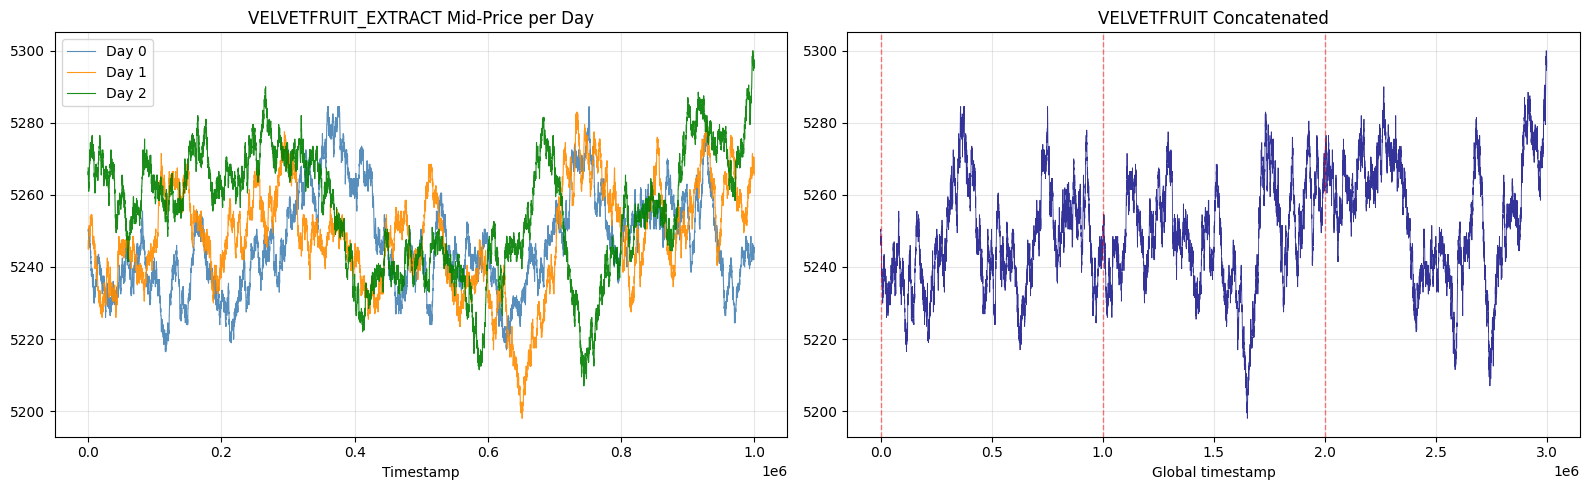

In [15]:
# 1b. Mid-price time series
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['steelblue', 'darkorange', 'green']
for day in [0,1,2]:
    d = und[und['day']==day]
    axes[0].plot(d['timestamp'], d['mid'], color=colors[day], label=f'Day {day}', lw=0.8, alpha=0.9)
axes[0].set_title('VELVETFRUIT_EXTRACT Mid-Price per Day')
axes[0].legend()
axes[0].set_xlabel('Timestamp')

axes[1].plot(und['global_ts'], und['mid'], lw=0.6, alpha=0.8, color='navy')
for day in [0,1,2]:
    axes[1].axvline(day*1_000_000, color='red', lw=1, ls='--', alpha=0.5)
axes[1].set_title('VELVETFRUIT Concatenated')
axes[1].set_xlabel('Global timestamp')
plt.tight_layout()
plt.show()

Spread distribution:
count    30000.0000
mean         4.9881
std          0.8471
min          1.0000
25%          5.0000
50%          5.0000
75%          5.0000
max          6.0000
Name: spread, dtype: float64

Spread value counts (top 15):
spread
5    22259
6     5475
2     1014
3     1003
1      178
4       71
Name: count, dtype: int64


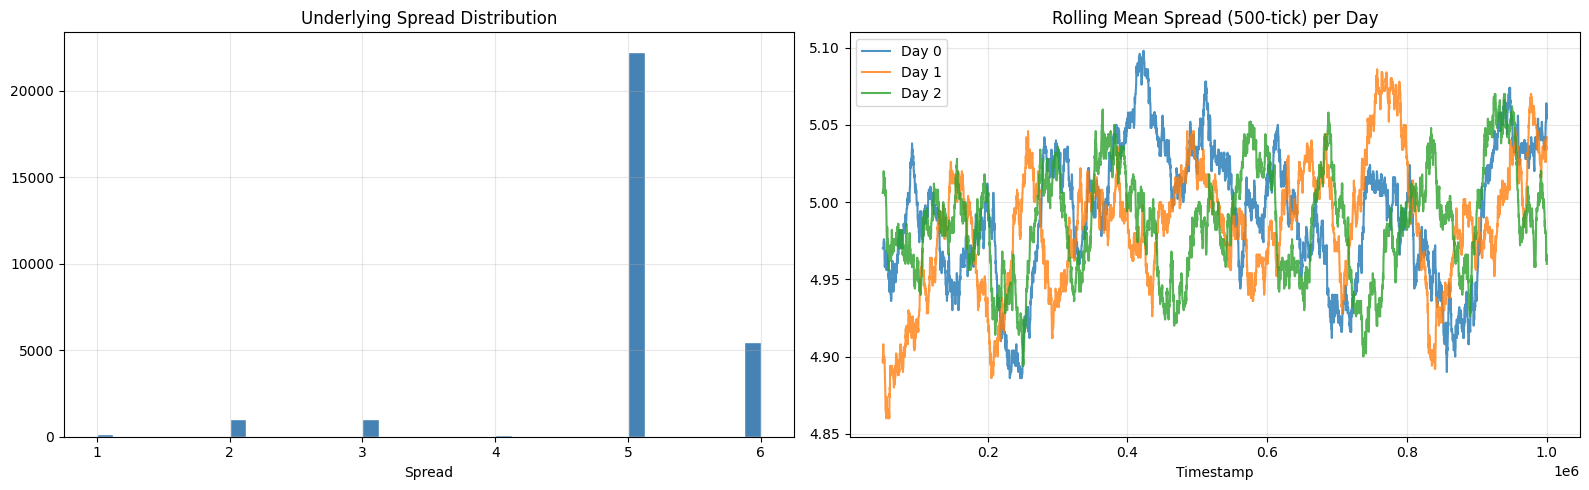

In [16]:
# 1c. Spread analysis
print('Spread distribution:')
print(und['spread'].describe().round(4))
print('\nSpread value counts (top 15):')
print(und['spread'].value_counts().head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(und['spread'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Underlying Spread Distribution')
axes[0].set_xlabel('Spread')

for day in [0,1,2]:
    d = und[und['day']==day]
    axes[1].plot(d['timestamp'], d['spread'].rolling(500).mean(), label=f'Day {day}', alpha=0.8)
axes[1].set_title('Rolling Mean Spread (500-tick) per Day')
axes[1].set_xlabel('Timestamp')
axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
# 1d. Returns and stationarity
und_mid = und['mid'].values
ret1_u  = np.diff(und_mid)
ret5_u  = und_mid[5:]  - und_mid[:-5]
ret10_u = und_mid[10:] - und_mid[:-10]

for lag, r in [(1, ret1_u), (5, ret5_u), (10, ret10_u)]:
    sk  = stats.skew(r)
    ku  = stats.kurtosis(r)
    _, pn = stats.normaltest(r)
    print(f'{lag:2d}-tick ret: mean={r.mean():.4f}  std={r.std():.4f}  skew={sk:.3f}  kurt={ku:.3f}  normality_p={pn:.3e}')

adf_res = adfuller(und_mid, autolag='AIC')
print(f'\nADF test: stat={adf_res[0]:.4f}  p={adf_res[1]:.4e}')
print('=> STATIONARY' if adf_res[1] < 0.05 else '=> NON-STATIONARY (random walk?)')

# AR(1)
slope_u, intercept_u, r_u, _, _ = stats.linregress(und_mid[:-1], und_mid[1:])
k_u  = 1 - slope_u
mu_u = intercept_u / k_u if k_u != 0 else np.nan
print(f'\nAR(1): beta={slope_u:.6f}  k={k_u:.6f}  mu={mu_u:.2f}  R²={r_u**2:.6f}')

 1-tick ret: mean=0.0015  std=1.1312  skew=-0.033  kurt=0.351  normality_p=2.090e-26
 5-tick ret: mean=0.0077  std=2.1873  skew=-0.016  kurt=0.008  normality_p=5.004e-01
10-tick ret: mean=0.0156  std=3.0255  skew=-0.003  kurt=-0.007  normality_p=9.521e-01

ADF test: stat=-4.8325  p=4.7118e-05
=> STATIONARY

AR(1): beta=0.997521  k=0.002479  mu=5250.71  R²=0.994769


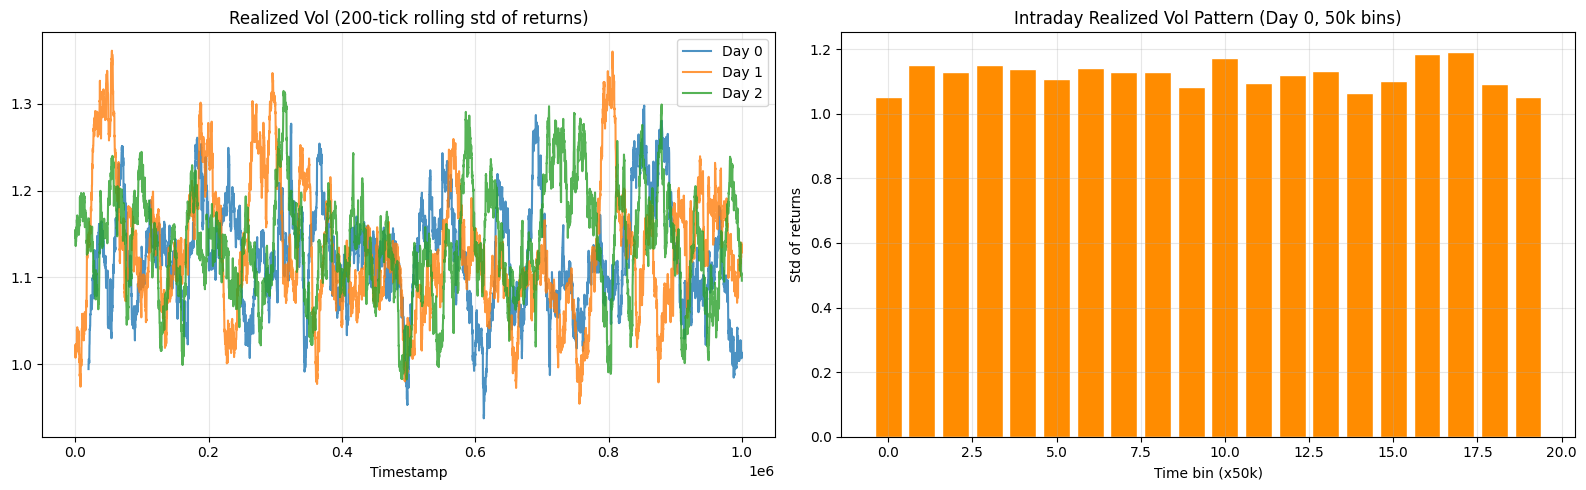

In [18]:
# 1e. Realized volatility (rolling)
WINDOW = 200
und['ret1'] = und['mid'].diff()
und['rvol'] = und['ret1'].rolling(WINDOW).std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for day in [0,1,2]:
    d = und[und['day']==day]
    axes[0].plot(d['timestamp'], d['rvol'], label=f'Day {day}', alpha=0.8)
axes[0].set_title(f'Realized Vol ({WINDOW}-tick rolling std of returns)')
axes[0].set_xlabel('Timestamp')
axes[0].legend()

# Intraday vol pattern (Day 0, 50k-tick bins)
d0 = und[und['day']==0].copy()
d0['bin'] = (d0['timestamp'] // 50000).astype(int)
intra_vol = d0.groupby('bin')['ret1'].std()
axes[1].bar(intra_vol.index, intra_vol.values, color='darkorange', edgecolor='white')
axes[1].set_title('Intraday Realized Vol Pattern (Day 0, 50k bins)')
axes[1].set_xlabel('Time bin (x50k)')
axes[1].set_ylabel('Std of returns')
plt.tight_layout()
plt.show()

In [19]:
# 1f. Book depth for underlying
for col in ['bid_volume_1','bid_volume_2','bid_volume_3','ask_volume_1','ask_volume_2','ask_volume_3']:
    und[col] = pd.to_numeric(und[col], errors='coerce').fillna(0)

print('Underlying depth stats:')
depth_cols = ['bid_volume_1','bid_volume_2','bid_volume_3','ask_volume_1','ask_volume_2','ask_volume_3']
print(und[depth_cols].describe().round(2))

und_obi = ((und['bid_volume_1'] - und['ask_volume_1']) /
           (und['bid_volume_1'] + und['ask_volume_1']).replace(0, np.nan))
und['obi'] = und_obi
ret_next = und['mid'].diff().shift(-1)
und['ret_next'] = ret_next
corr_obi = und[['obi','ret_next']].dropna().corr().iloc[0,1]
print(f'\nUnderlying OBI -> next-tick return corr: {corr_obi:.4f}')

Underlying depth stats:
       bid_volume_1  bid_volume_2  bid_volume_3  ask_volume_1  ask_volume_2  \
count      30000.00      30000.00      30000.00      30000.00      30000.00   
mean          37.83         21.73          0.81         37.80         21.80   
std           21.02         20.77          5.73         21.05         20.75   
min            1.00          0.00          0.00          1.00          0.00   
25%           19.00          0.00          0.00         19.00          0.00   
50%           25.00         30.00          0.00         25.00         31.00   
75%           59.00         41.00          0.00         59.00         41.00   
max           75.00         75.00         63.00         75.00         75.00   

       ask_volume_3  
count      30000.00  
mean           0.77  
std            5.59  
min            0.00  
25%            0.00  
50%            0.00  
75%            0.00  
max           58.00  

Underlying OBI -> next-tick return corr: 0.2806


In [20]:
# ════════════════════════════════════════════════════════════════════════════
# PART 2: OPTIONS OVERVIEW
# ════════════════════════════════════════════════════════════════════════════

# Align underlying and each option on (day, timestamp)
und_lookup = und.set_index(['day','timestamp'])['mid']

summary_rows = []
for k, sym in zip(STRIKES, OPT_SYMS):
    df = opts[sym].copy()
    # get underlying price at same day/timestamp
    df['S'] = df.apply(lambda r: und_lookup.get((r['day'], r['timestamp']), np.nan), axis=1)
    df['intrinsic'] = np.maximum(df['S'] - k, 0)
    df['time_value'] = df['mid'] - df['intrinsic']
    df['moneyness']  = (df['S'] - k) / df['S']
    opts[sym] = df

    row = {
        'strike': k,
        'avg_mid':        df['mid'].mean(),
        'avg_S':          df['S'].mean(),
        'avg_intrinsic':  df['intrinsic'].mean(),
        'avg_time_value': df['time_value'].mean(),
        'avg_moneyness':  df['moneyness'].mean(),
        'avg_spread':     df['spread'].mean(),
        'avg_depth_bid1': pd.to_numeric(df['bid_volume_1'], errors='coerce').mean(),
        'avg_depth_ask1': pd.to_numeric(df['ask_volume_1'], errors='coerce').mean(),
    }
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary['moneyness_label'] = summary['avg_moneyness'].apply(
    lambda m: 'Deep ITM' if m > 0.03 else ('ITM' if m > 0.005 else ('ATM' if abs(m) <= 0.005 else ('OTM' if m > -0.03 else 'Deep OTM')))
)
print(summary[['strike','avg_mid','avg_S','avg_intrinsic','avg_time_value','avg_moneyness','avg_spread','moneyness_label']].to_string(index=False))

 strike     avg_mid     avg_S  avg_intrinsic  avg_time_value  avg_moneyness  avg_spread moneyness_label
   4000 1250.109800 5250.0981    1250.098100        0.011700       0.238103   20.813467        Deep ITM
   4500  750.109567 5250.0981     750.098100        0.011467       0.142866   15.852667        Deep ITM
   5000  255.022400 5250.0981     250.098100        4.924300       0.047628    6.043333        Deep ITM
   5100  166.805450 5250.0981     150.098100       16.707350       0.028581    4.295833             ITM
   5200   95.548767 5250.0981      50.098383       45.450383       0.009534    2.888133             ITM
   5300   46.759933 5250.0981       0.000000       46.759933      -0.009514    2.106800             OTM
   5400   15.951917 5250.0981       0.000000       15.951917      -0.028561    1.381433             OTM
   5500    6.641350 5250.0981       0.000000        6.641350      -0.047609    1.149767        Deep OTM
   6000    0.500000 5250.0981       0.000000        0.500000    

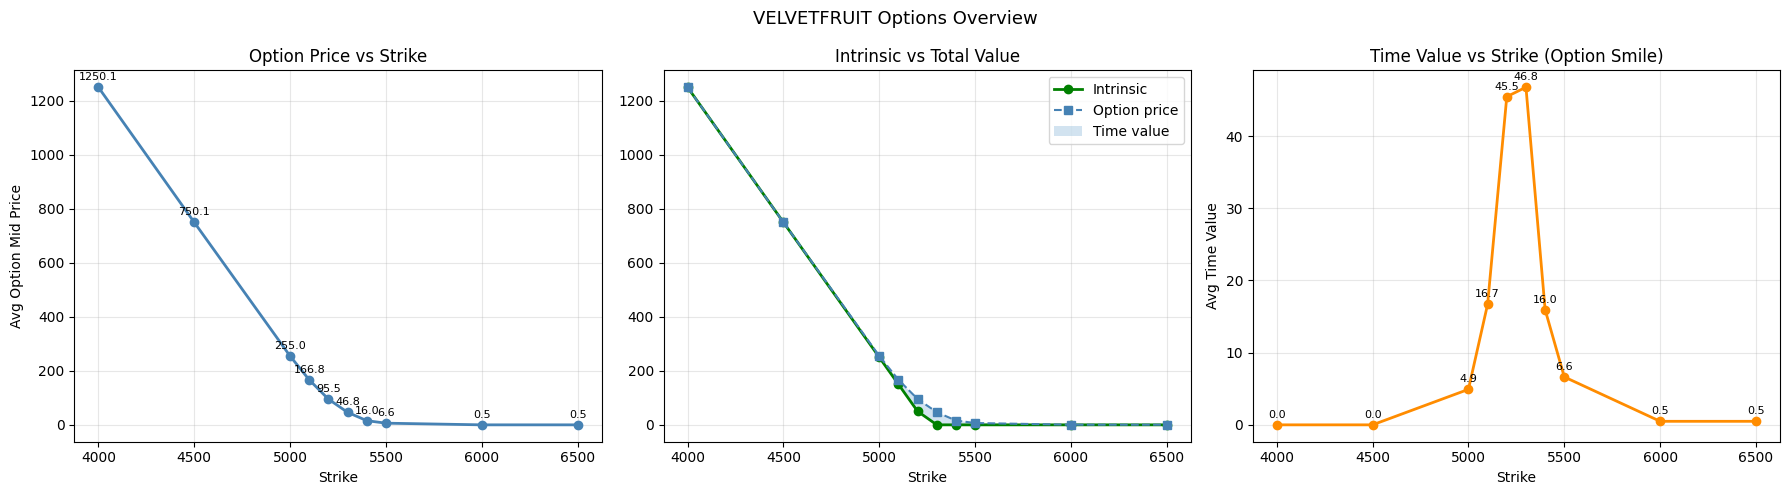

In [21]:
# Option price and time value smile
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(summary['strike'], summary['avg_mid'], 'o-', color='steelblue', lw=2)
axes[0].set_title('Option Price vs Strike')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Avg Option Mid Price')
for _, row in summary.iterrows():
    axes[0].annotate(f"{row['avg_mid']:.1f}", (row['strike'], row['avg_mid']), textcoords='offset points', xytext=(0,5), ha='center', fontsize=8)

axes[1].plot(summary['strike'], summary['avg_intrinsic'], 'o-', color='green', label='Intrinsic', lw=2)
axes[1].plot(summary['strike'], summary['avg_mid'],       's--', color='steelblue', label='Option price', lw=1.5)
axes[1].fill_between(summary['strike'], summary['avg_intrinsic'], summary['avg_mid'], alpha=0.2, label='Time value')
axes[1].set_title('Intrinsic vs Total Value')
axes[1].set_xlabel('Strike')
axes[1].legend()

axes[2].plot(summary['strike'], summary['avg_time_value'], 'o-', color='darkorange', lw=2)
axes[2].set_title('Time Value vs Strike (Option Smile)')
axes[2].set_xlabel('Strike')
axes[2].set_ylabel('Avg Time Value')
for _, row in summary.iterrows():
    axes[2].annotate(f"{row['avg_time_value']:.1f}", (row['strike'], row['avg_time_value']), textcoords='offset points', xytext=(0,5), ha='center', fontsize=8)

plt.suptitle('VELVETFRUIT Options Overview', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# ════════════════════════════════════════════════════════════════════════════
# PART 3: IMPLIED VOLATILITY CALIBRATION
# ════════════════════════════════════════════════════════════════════════════

from scipy.stats import norm as _norm

def bs_call(S, K, T, r, sigma):
    """Black-Scholes call price."""
    if sigma <= 0 or T <= 0 or S <= 0:
        return max(S - K, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * _norm.cdf(d1) - K * np.exp(-r*T) * _norm.cdf(d2)

def bs_delta(S, K, T, r, sigma):
    if sigma <= 0 or T <= 0 or S <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    return _norm.cdf(d1)

def bs_gamma(S, K, T, r, sigma):
    if sigma <= 0 or T <= 0 or S <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    return _norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    if sigma <= 0 or T <= 0 or S <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    return S * _norm.pdf(d1) * np.sqrt(T)

def implied_vol(C_market, S, K, T=1.0, r=0.0):
    intrinsic = max(S - K, 0)
    if C_market <= intrinsic + 1e-6 or C_market <= 0 or S <= 0:
        return np.nan
    try:
        iv = optimize.brentq(lambda v: bs_call(S, K, T, r, v) - C_market, 1e-4, 20.0, xtol=1e-6)
        return iv
    except:
        return np.nan

# Compute IV for each option on a sampled subset (every 10 ticks for speed)
T_NORM = 1.0  # normalized time to expiry
R      = 0.0

iv_data = {}
for k, sym in zip(STRIKES, OPT_SYMS):
    df = opts[sym].iloc[::10].copy()
    ivs = []
    for _, row in df.iterrows():
        S = row['S']
        C = row['mid']
        if pd.isna(S) or pd.isna(C):
            ivs.append(np.nan)
        else:
            ivs.append(implied_vol(C, S, k, T_NORM, R))
    df['iv'] = ivs
    iv_data[sym] = df
    valid = df['iv'].dropna()
    print(f'VEV_{k:5d}: IV mean={valid.mean():.4f}  std={valid.std():.4f}  '
          f'min={valid.min():.4f}  max={valid.max():.4f}  valid={len(valid)}/{len(df)}')

VEV_ 4000: IV mean=0.1085  std=0.0108  min=0.0978  max=0.1423  valid=310/3000
VEV_ 4500: IV mean=0.0621  std=0.0046  min=0.0576  max=0.0854  valid=825/3000
VEV_ 5000: IV mean=0.0322  std=0.0022  min=0.0234  max=0.0376  valid=2997/3000
VEV_ 5100: IV mean=0.0319  std=0.0026  min=0.0265  max=0.0368  valid=3000/3000
VEV_ 5200: IV mean=0.0323  std=0.0021  min=0.0280  max=0.0360  valid=3000/3000
VEV_ 5300: IV mean=0.0326  std=0.0018  min=0.0283  max=0.0362  valid=3000/3000
VEV_ 5400: IV mean=0.0306  std=0.0021  min=0.0268  max=0.0359  valid=3000/3000
VEV_ 5500: IV mean=0.0331  std=0.0020  min=0.0285  max=0.0364  valid=3000/3000
VEV_ 6000: IV mean=0.0523  std=0.0010  min=0.0490  max=0.0556  valid=3000/3000
VEV_ 6500: IV mean=0.0793  std=0.0010  min=0.0761  max=0.0825  valid=3000/3000


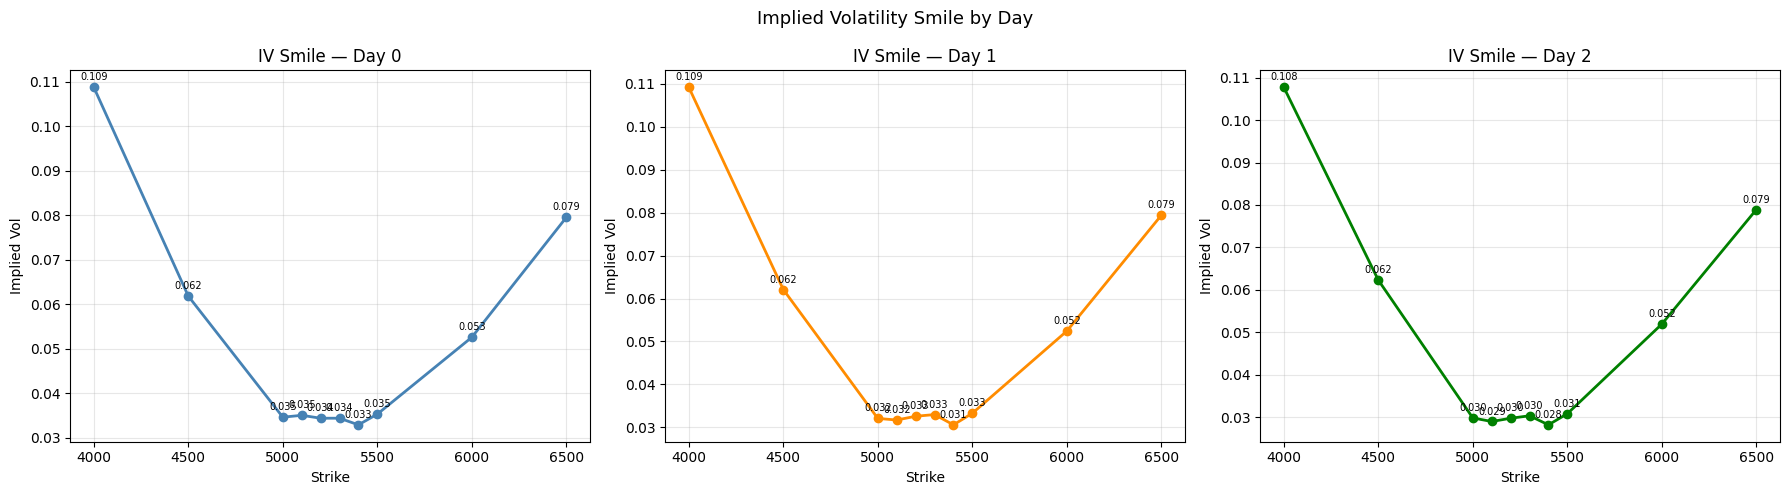

In [23]:
# IV smile plot (per day)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_day = ['steelblue','darkorange','green']

for i, day in enumerate([0,1,2]):
    iv_by_strike = []
    for k, sym in zip(STRIKES, OPT_SYMS):
        df = iv_data[sym]
        d  = df[df['day']==day]['iv'].dropna()
        iv_by_strike.append(d.mean() if len(d) > 0 else np.nan)
    axes[i].plot(STRIKES, iv_by_strike, 'o-', color=colors_day[i], lw=2)
    axes[i].set_title(f'IV Smile — Day {day}')
    axes[i].set_xlabel('Strike')
    axes[i].set_ylabel('Implied Vol')
    for k, iv in zip(STRIKES, iv_by_strike):
        if not np.isnan(iv):
            axes[i].annotate(f'{iv:.3f}', (k, iv), textcoords='offset points', xytext=(0,5), ha='center', fontsize=7)

plt.suptitle('Implied Volatility Smile by Day', fontsize=13)
plt.tight_layout()
plt.show()

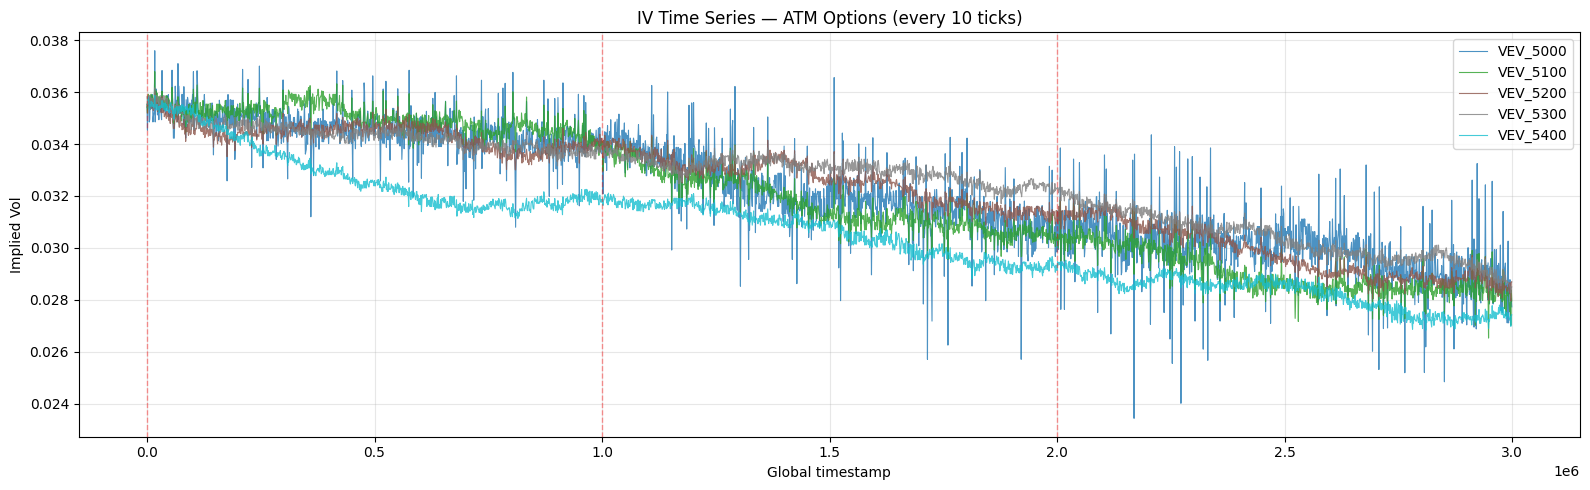


IV stability (std of IV per strike):
  VEV_4000: std=0.01082  mean=0.1085
  VEV_4500: std=0.00457  mean=0.0621
  VEV_5000: std=0.00224  mean=0.0322
  VEV_5100: std=0.00259  mean=0.0319
  VEV_5200: std=0.00205  mean=0.0323
  VEV_5300: std=0.00178  mean=0.0326
  VEV_5400: std=0.00215  mean=0.0306
  VEV_5500: std=0.00199  mean=0.0331
  VEV_6000: std=0.00105  mean=0.0523
  VEV_6500: std=0.00100  mean=0.0793


In [24]:
# IV time series for ATM options (VEV_5200, VEV_5300)
fig, ax = plt.subplots(figsize=(16, 5))
atm_strikes = [5000, 5100, 5200, 5300, 5400]
palette = cm.tab10(np.linspace(0, 1, len(atm_strikes)))

for k, color in zip(atm_strikes, palette):
    sym = f'VEV_{k}'
    if sym not in iv_data: continue
    df = iv_data[sym]
    ax.plot(df['global_ts'], df['iv'], label=f'VEV_{k}', lw=0.8, color=color, alpha=0.8)

for day in [0,1,2]:
    ax.axvline(day*1_000_000, color='red', lw=1, ls='--', alpha=0.4)
ax.set_title('IV Time Series — ATM Options (every 10 ticks)')
ax.set_xlabel('Global timestamp')
ax.set_ylabel('Implied Vol')
ax.legend()
plt.tight_layout()
plt.show()

# IV stability: std per strike
print('\nIV stability (std of IV per strike):')
for k, sym in zip(STRIKES, OPT_SYMS):
    iv_series = iv_data[sym]['iv'].dropna()
    print(f'  VEV_{k}: std={iv_series.std():.5f}  mean={iv_series.mean():.4f}')

In [25]:
# Vol skew analysis
# Skew: IV(OTM_put equivalent = low strike calls) vs IV(OTM_call = high strike calls)
iv_means = {}
for k, sym in zip(STRIKES, OPT_SYMS):
    iv_means[k] = iv_data[sym]['iv'].dropna().mean()

S_avg = und['mid'].mean()
print(f'Avg underlying price: {S_avg:.2f}')
print('\nIV by strike (skew analysis):')
print(f'{"Strike":>8}  {"Avg IV":>8}  {"Moneyness (S-K)/S":>18}  {"Side":>8}')
for k in STRIKES:
    m = (S_avg - k) / S_avg
    side = 'ITM' if m > 0.01 else ('ATM' if abs(m) <= 0.01 else 'OTM')
    print(f'{k:8d}  {iv_means.get(k, float("nan")):8.4f}  {m:18.4f}  {side:>8}')

# Is there a smile or skew?
iv_vs_strike = [(k, iv_means.get(k, np.nan)) for k in STRIKES if not np.isnan(iv_means.get(k, np.nan))]
if len(iv_vs_strike) >= 3:
    ks, ivs_list = zip(*iv_vs_strike)
    slope_iv, intercept_iv, r_iv, _, _ = stats.linregress(ks, ivs_list)
    print(f'\nIV vs Strike linear fit: slope={slope_iv:.6f}  (negative=downward skew, positive=upward)')

Avg underlying price: 5250.10

IV by strike (skew analysis):
  Strike    Avg IV   Moneyness (S-K)/S      Side
    4000    0.1085              0.2381       ITM
    4500    0.0621              0.1429       ITM
    5000    0.0322              0.0476       ITM
    5100    0.0319              0.0286       ITM
    5200    0.0323              0.0095       ATM
    5300    0.0326             -0.0095       ATM
    5400    0.0306             -0.0286       OTM
    5500    0.0331             -0.0476       OTM
    6000    0.0523             -0.1428       OTM
    6500    0.0793             -0.2381       OTM

IV vs Strike linear fit: slope=-0.000010  (negative=downward skew, positive=upward)


In [26]:
# ADF stationarity of IV per strike
print('IV stationarity (ADF test):')
for k, sym in zip(STRIKES, OPT_SYMS):
    iv_series = iv_data[sym]['iv'].dropna()
    if len(iv_series) < 20:
        print(f'  VEV_{k}: insufficient data')
        continue
    try:
        adf_iv = adfuller(iv_series.values, autolag='AIC')
        stat_str = 'STATIONARY' if adf_iv[1] < 0.05 else 'NON-STATIONARY'
        print(f'  VEV_{k}: p={adf_iv[1]:.4f}  [{stat_str}]')
    except:
        print(f'  VEV_{k}: ADF failed')

IV stationarity (ADF test):
  VEV_4000: p=0.0000  [STATIONARY]
  VEV_4500: p=0.0000  [STATIONARY]
  VEV_5000: p=0.8624  [NON-STATIONARY]
  VEV_5100: p=0.9275  [NON-STATIONARY]
  VEV_5200: p=0.9569  [NON-STATIONARY]
  VEV_5300: p=0.9921  [NON-STATIONARY]
  VEV_5400: p=0.1814  [NON-STATIONARY]
  VEV_5500: p=0.9901  [NON-STATIONARY]
  VEV_6000: p=0.0000  [STATIONARY]
  VEV_6500: p=0.0000  [STATIONARY]


In [27]:
# Correlation: underlying moves vs IV changes (vol feedback)
print('Correlation: underlying return vs IV change per strike:')
und_ret_ts = {}
for day in [0,1,2]:
    d = und[und['day']==day].set_index('timestamp')['mid']
    for ts, m in d.items():
        und_ret_ts[(day, ts)] = m

for k, sym in zip(STRIKES, OPT_SYMS):
    df = iv_data[sym].copy()
    df['iv_chg'] = df['iv'].diff()
    df['S_ret']  = df['S'].pct_change()
    v = df[['iv_chg','S_ret']].dropna()
    if len(v) < 10:
        continue
    c, p = stats.pearsonr(v['S_ret'], v['iv_chg'])
    print(f'  VEV_{k}: corr={c:.4f}  p={p:.3e}')

Correlation: underlying return vs IV change per strike:
  VEV_4000: corr=-0.5987  p=1.996e-03
  VEV_4500: corr=-0.1720  p=5.690e-03
  VEV_5000: corr=-0.1545  p=1.903e-17
  VEV_5100: corr=-0.1739  p=8.669e-22
  VEV_5200: corr=-0.1543  p=1.984e-17
  VEV_5300: corr=-0.1187  p=7.050e-11
  VEV_5400: corr=-0.1055  p=6.972e-09
  VEV_5500: corr=-0.0412  p=2.402e-02
  VEV_6000: corr=-1.0000  p=0.000e+00
  VEV_6500: corr=-1.0000  p=0.000e+00


Options spread and liquidity summary:
  Strike   AvgSpread   MedianSpread   AvgBidVol1   AvgAskVol1  MoneyLabel
    4000      20.813         21.000        10.92        10.92    Deep ITM
    4500      15.853         16.000         8.95         8.95    Deep ITM
    5000       6.043          6.000        15.33        15.48    Deep ITM
    5100       4.296          4.000        19.25        19.35         ITM
    5200       2.888          3.000        22.56        22.51         ITM
    5300       2.107          2.000        20.28        20.24         OTM
    5400       1.381          1.000        21.76        21.72         OTM
    5500       1.150          1.000        22.18        22.17    Deep OTM
    6000       1.000          1.000        22.48        22.48    Deep OTM
    6500       1.000          1.000        15.48        15.48    Deep OTM


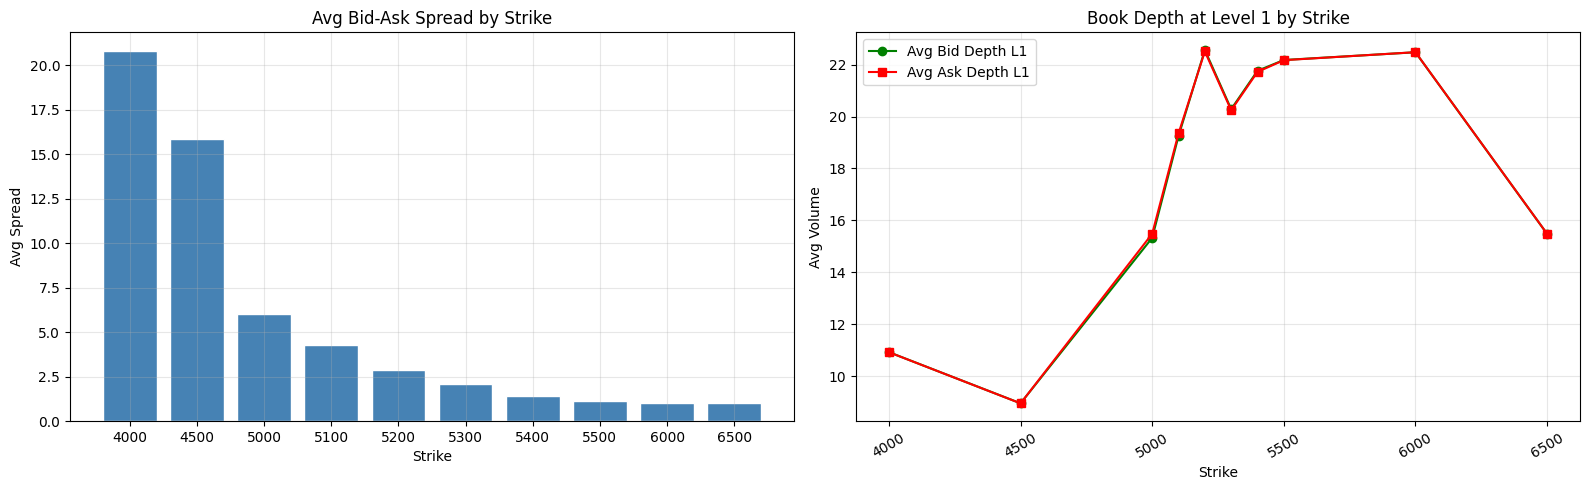

In [28]:
# ════════════════════════════════════════════════════════════════════════════
# PART 4: OPTIONS SPREAD AND LIQUIDITY
# ════════════════════════════════════════════════════════════════════════════

print('Options spread and liquidity summary:')
print(f'{"Strike":>8}  {"AvgSpread":>10}  {"MedianSpread":>13}  {"AvgBidVol1":>11}  {"AvgAskVol1":>11}  {"MoneyLabel":>10}')
for _, row in summary.iterrows():
    print(f'{int(row["strike"]):8d}  {row["avg_spread"]:10.3f}  {opts[f"VEV_{int(row["strike"])}"]["spread"].median():13.3f}  '
          f'{row["avg_depth_bid1"]:11.2f}  {row["avg_depth_ask1"]:11.2f}  {row["moneyness_label"]:>10}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar([str(k) for k in STRIKES], summary['avg_spread'], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Bid-Ask Spread by Strike')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Avg Spread')
plt.xticks(rotation=30)

axes[1].plot(summary['strike'], summary['avg_depth_bid1'], 'o-', label='Avg Bid Depth L1', color='green')
axes[1].plot(summary['strike'], summary['avg_depth_ask1'], 's-', label='Avg Ask Depth L1', color='red')
axes[1].set_title('Book Depth at Level 1 by Strike')
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('Avg Volume')
axes[1].legend()
plt.tight_layout()
plt.show()

In [29]:
# Deep ITM analysis: VEV_4000, VEV_4500
print('Deep ITM options analysis:')
for k in [4000, 4500]:
    sym = f'VEV_{k}'
    df  = opts[sym]
    intrinsic_vals = df['intrinsic'].dropna()
    mid_vals = df['mid'].dropna()
    tv_vals  = df['time_value'].dropna()
    spread_vals = df['spread'].dropna()
    print(f'  VEV_{k}:')
    print(f'    Avg intrinsic:  {intrinsic_vals.mean():.2f}')
    print(f'    Avg mid:        {mid_vals.mean():.2f}')
    print(f'    Avg time value: {tv_vals.mean():.4f}')
    print(f'    Spread dist:    mean={spread_vals.mean():.3f}  max={spread_vals.max():.1f}')
    print(f'    Pct time_value < 0: {(tv_vals < 0).mean()*100:.2f}% (arbitrage if > 0%)')
    print()

Deep ITM options analysis:
  VEV_4000:
    Avg intrinsic:  1250.10
    Avg mid:        1250.11
    Avg time value: 0.0117
    Spread dist:    mean=20.813  max=22.0
    Pct time_value < 0: 9.95% (arbitrage if > 0%)

  VEV_4500:
    Avg intrinsic:  750.10
    Avg mid:        750.11
    Avg time value: 0.0115
    Spread dist:    mean=15.853  max=17.0
    Pct time_value < 0: 29.37% (arbitrage if > 0%)



In [30]:
# ════════════════════════════════════════════════════════════════════════════
# PART 5: DELTA HEDGING
# ════════════════════════════════════════════════════════════════════════════

# Compute BS delta and gamma for each option (sampled)
greek_rows = []
for k, sym in zip(STRIKES, OPT_SYMS):
    df = iv_data[sym].copy()
    df['delta'] = df.apply(
        lambda r: bs_delta(r['S'], k, T_NORM, R, r['iv']) if not np.isnan(r.get('iv', np.nan)) else np.nan, axis=1)
    df['gamma'] = df.apply(
        lambda r: bs_gamma(r['S'], k, T_NORM, R, r['iv']) if not np.isnan(r.get('iv', np.nan)) else np.nan, axis=1)
    df['vega']  = df.apply(
        lambda r: bs_vega(r['S'], k, T_NORM, R, r['iv']) if not np.isnan(r.get('iv', np.nan)) else np.nan, axis=1)
    df['strike'] = k
    greek_rows.append(df)
    d_mean = df['delta'].dropna().mean()
    g_mean = df['gamma'].dropna().mean()
    v_mean = df['vega'].dropna().mean()
    print(f'VEV_{k}: delta={d_mean:.4f}  gamma={g_mean:.6f}  vega={v_mean:.4f}')

greeks = pd.concat(greek_rows, ignore_index=True)

VEV_4000: delta=0.9940  gamma=0.000027  vega=86.4237
VEV_4500: delta=0.9936  gamma=0.000053  vega=93.0446
VEV_5000: delta=0.9360  gamma=0.000727  vega=649.7040
VEV_5100: delta=0.8222  gamma=0.001541  vega=1355.2721
VEV_5200: delta=0.6233  gamma=0.002239  vega=1983.5442
VEV_5300: delta=0.3925  gamma=0.002245  vega=2009.9982
VEV_5400: delta=0.1832  gamma=0.001648  vega=1385.9638
VEV_5500: delta=0.0835  gamma=0.000875  vega=801.7191
VEV_6000: delta=0.0058  gamma=0.000060  vega=86.2413
VEV_6500: delta=0.0040  gamma=0.000028  vega=61.8001


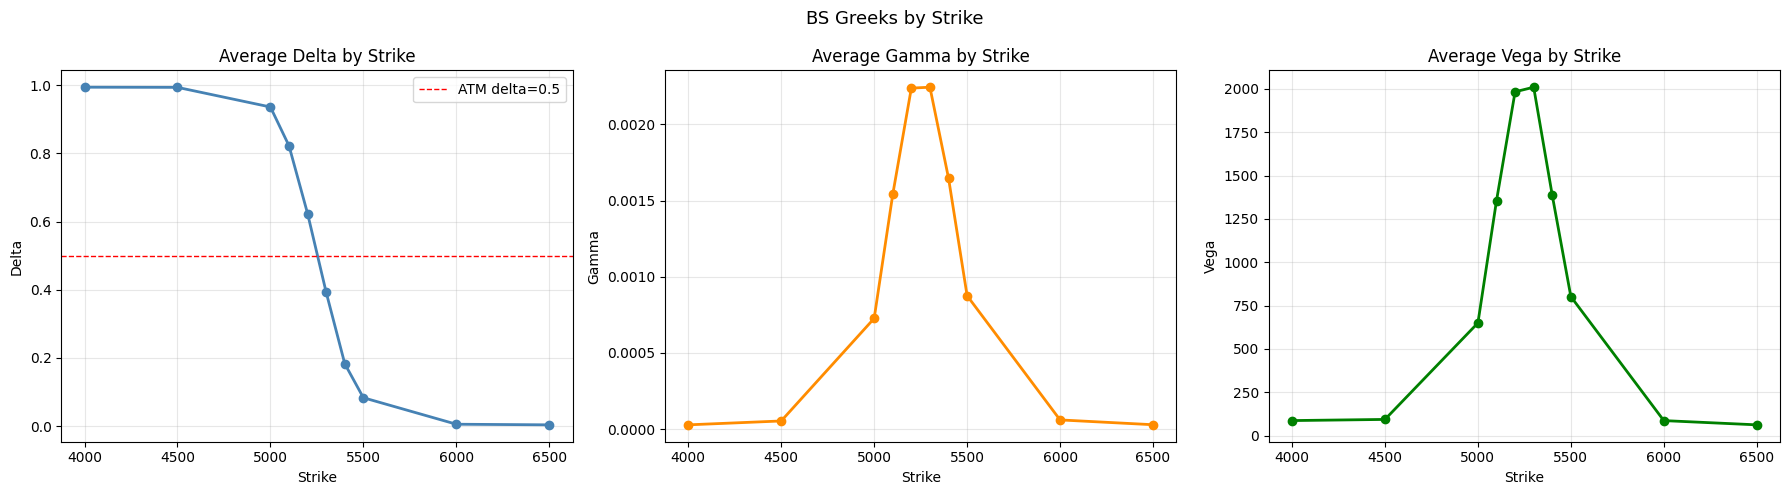

In [31]:
# Delta smile (delta vs strike)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

avg_by_strike = greeks.groupby('strike')[['delta','gamma','vega']].mean().reset_index()

axes[0].plot(avg_by_strike['strike'], avg_by_strike['delta'], 'o-', color='steelblue', lw=2)
axes[0].axhline(0.5, color='red', ls='--', lw=1, label='ATM delta=0.5')
axes[0].set_title('Average Delta by Strike')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Delta')
axes[0].legend()

axes[1].plot(avg_by_strike['strike'], avg_by_strike['gamma'], 'o-', color='darkorange', lw=2)
axes[1].set_title('Average Gamma by Strike')
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('Gamma')

axes[2].plot(avg_by_strike['strike'], avg_by_strike['vega'], 'o-', color='green', lw=2)
axes[2].set_title('Average Vega by Strike')
axes[2].set_xlabel('Strike')
axes[2].set_ylabel('Vega')

plt.suptitle('BS Greeks by Strike', fontsize=13)
plt.tight_layout()
plt.show()

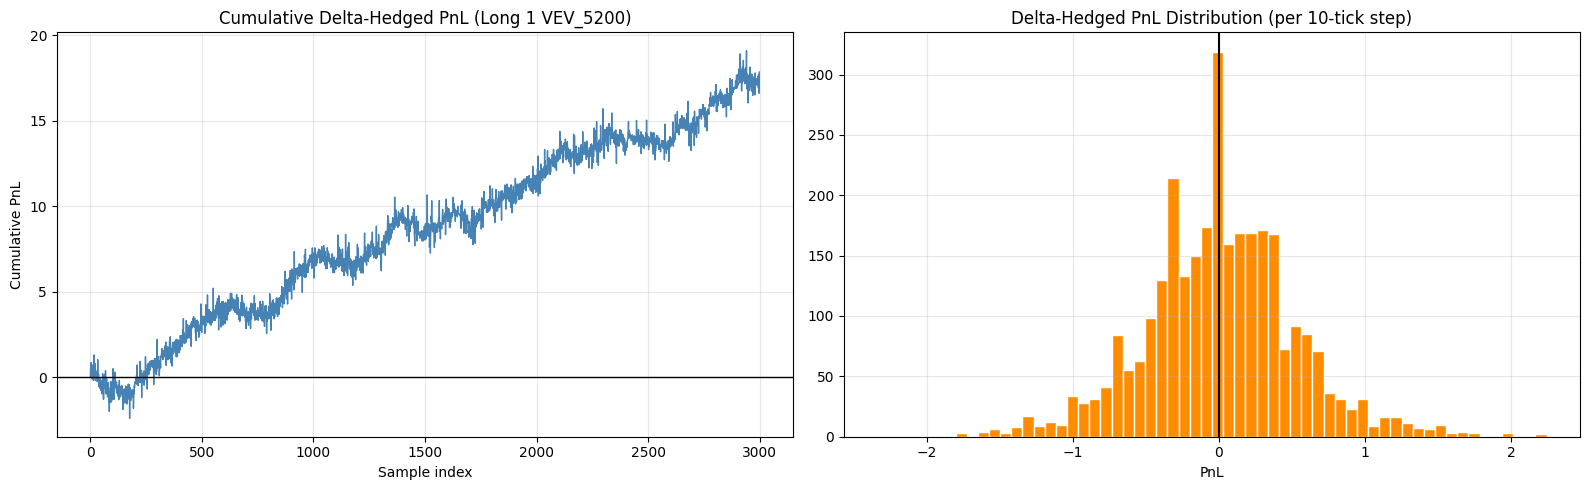

Total delta-hedged PnL (long 1 VEV_5200): 17.8441


In [32]:
# Delta-hedge PnL simulation for 1 ATM option
# Strategy: buy 1 unit of VEV_5200, delta-hedge with VELVETFRUIT
# Rebalance every 10 ticks
ATM_K = 5200
ATM_SYM = f'VEV_{ATM_K}'

df_atm = iv_data[ATM_SYM].copy()
df_atm['delta'] = df_atm.apply(
    lambda r: bs_delta(r['S'], ATM_K, T_NORM, R, r['iv']) if not np.isnan(r.get('iv', np.nan)) else 0.5, axis=1)

# Simulate
opt_position  = 1.0
hedge_position = 0.0
cash = 0.0
pnl_series = []
prev_opt_price = None
prev_S = None
prev_delta = 0.0

for i, row in df_atm.iterrows():
    S   = row['S']
    C   = row['mid']
    d   = row['delta']
    if pd.isna(S) or pd.isna(C) or pd.isna(d):
        pnl_series.append(np.nan)
        continue
    if prev_opt_price is not None and prev_S is not None:
        pnl = (C - prev_opt_price) * opt_position + (S - prev_S) * hedge_position
        pnl_series.append(pnl)
    else:
        pnl_series.append(0.0)
    # Update hedge
    hedge_target = -d * opt_position
    hedge_position = hedge_target
    prev_opt_price = C
    prev_S = S

df_atm['pnl'] = pnl_series
cumulative_pnl = df_atm['pnl'].fillna(0).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(cumulative_pnl.values, color='steelblue', lw=1)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title(f'Cumulative Delta-Hedged PnL (Long 1 VEV_{ATM_K})')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Cumulative PnL')

axes[1].hist(df_atm['pnl'].dropna(), bins=60, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_title('Delta-Hedged PnL Distribution (per 10-tick step)')
axes[1].set_xlabel('PnL')
plt.tight_layout()
plt.show()

net_pnl = df_atm['pnl'].fillna(0).sum()
print(f'Total delta-hedged PnL (long 1 VEV_{ATM_K}): {net_pnl:.4f}')

In [33]:
# ════════════════════════════════════════════════════════════════════════════
# PART 6: ARBITRAGE CHECKS
# ════════════════════════════════════════════════════════════════════════════

# 6a. Monotonicity: call prices must decrease as strike increases
# Check for each tick how often monotonicity is violated
violations_mono = 0
total_checks = 0

# Merge all options on (day, timestamp)
opt_mids = {}
for k, sym in zip(STRIKES, OPT_SYMS):
    tmp = opts[sym].set_index(['day','timestamp'])['mid']
    opt_mids[k] = tmp

common_idx = opt_mids[STRIKES[0]].index
for i in range(0, len(common_idx), 10):  # sample every 10 ticks
    idx = common_idx[i]
    prices_at_t = [opt_mids[k].get(idx, np.nan) for k in STRIKES]
    if any(np.isnan(p) for p in prices_at_t):
        continue
    for j in range(len(STRIKES)-1):
        total_checks += 1
        if prices_at_t[j] < prices_at_t[j+1]:  # call price should decrease with strike
            violations_mono += 1

print(f'Monotonicity violations: {violations_mono}/{total_checks} ({violations_mono/total_checks*100:.2f}%)')

# 6b. Convexity (butterfly): C(K-dK) + C(K+dK) >= 2*C(K)
violations_conv = 0
checks_conv = 0
mid_strikes = STRIKES[1:-1]

for i in range(0, len(common_idx), 10):
    idx = common_idx[i]
    prices_at_t = {k: opt_mids[k].get(idx, np.nan) for k in STRIKES}
    if any(np.isnan(v) for v in prices_at_t.values()):
        continue
    for j, k in enumerate(STRIKES[1:-1]):
        k_lower = STRIKES[j]
        k_upper = STRIKES[j+2]
        w = (k_upper - k) / (k_upper - k_lower)
        convex_bound = w * prices_at_t[k_lower] + (1-w) * prices_at_t[k_upper]
        checks_conv += 1
        if prices_at_t[k] > convex_bound + 0.5:  # 0.5 tolerance for bid-ask
            violations_conv += 1

print(f'Convexity (butterfly) violations: {violations_conv}/{checks_conv} ({violations_conv/checks_conv*100:.2f}%)')

Monotonicity violations: 0/27000 (0.00%)
Convexity (butterfly) violations: 0/24000 (0.00%)


Relative value vs fitted quadratic smile (IV residual):
  Strike    Avg IV  Fitted IV   Residual    Signal
    4000    0.1085     0.1072     0.0013   NEUTRAL
    4500    0.0621     0.0618     0.0003   NEUTRAL
    5000    0.0322     0.0366    -0.0044   NEUTRAL
    5100    0.0319     0.0340    -0.0020   NEUTRAL
    5200    0.0323     0.0322     0.0001   NEUTRAL
    5300    0.0326     0.0312     0.0014   NEUTRAL
    5400    0.0306     0.0310    -0.0004   NEUTRAL
    5500    0.0331     0.0316     0.0015   NEUTRAL
    6000    0.0523     0.0469     0.0054      SELL
    6500    0.0793     0.0825    -0.0032   NEUTRAL


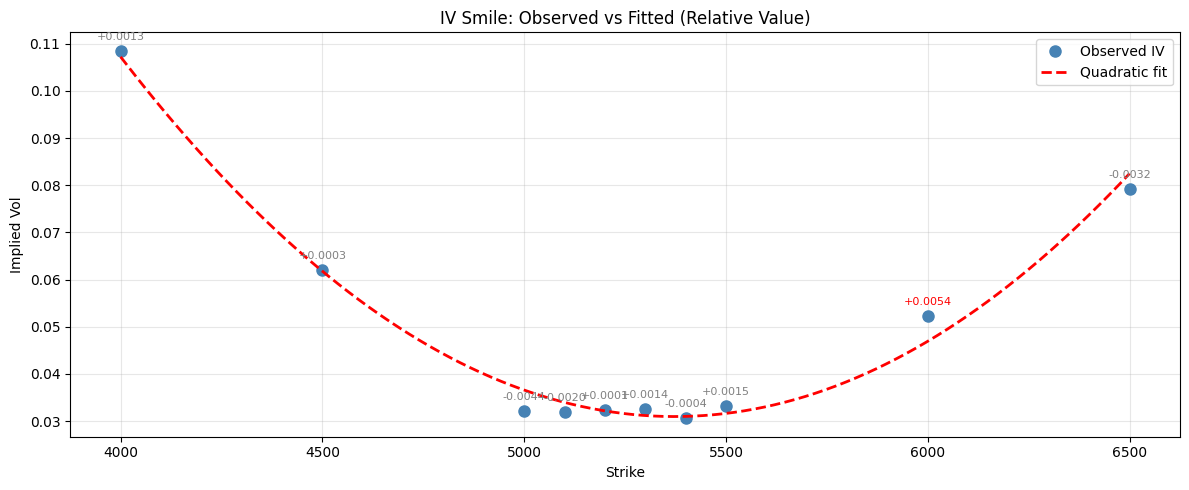

In [34]:
# 6c. Relative value: compare each option's IV to fitted smile
# Fit a quadratic IV smile and find deviations
iv_means_arr = np.array([iv_means.get(k, np.nan) for k in STRIKES])
valid_mask = ~np.isnan(iv_means_arr)

if valid_mask.sum() >= 3:
    coeffs = np.polyfit(np.array(STRIKES)[valid_mask], iv_means_arr[valid_mask], 2)
    iv_fitted = np.polyval(coeffs, np.array(STRIKES))
    iv_resid = iv_means_arr - iv_fitted

    print('Relative value vs fitted quadratic smile (IV residual):')
    print(f'{"Strike":>8}  {"Avg IV":>8}  {"Fitted IV":>9}  {"Residual":>9}  {"Signal":>8}')
    for k, iv_m, iv_f, resid in zip(STRIKES, iv_means_arr, iv_fitted, iv_resid):
        signal = 'BUY' if resid < -0.005 else ('SELL' if resid > 0.005 else 'NEUTRAL')
        print(f'{k:8d}  {iv_m:8.4f}  {iv_f:9.4f}  {resid:9.4f}  {signal:>8}')

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(STRIKES, iv_means_arr, 'o', color='steelblue', ms=8, label='Observed IV')
    k_smooth = np.linspace(STRIKES[0], STRIKES[-1], 200)
    ax.plot(k_smooth, np.polyval(coeffs, k_smooth), 'r--', lw=2, label='Quadratic fit')
    for k, iv_m, resid in zip(STRIKES, iv_means_arr, iv_resid):
        if not np.isnan(iv_m):
            color = 'green' if resid < -0.005 else ('red' if resid > 0.005 else 'gray')
            ax.annotate(f'{resid:+.4f}', (k, iv_m), textcoords='offset points', xytext=(0,8),
                       ha='center', fontsize=8, color=color)
    ax.set_title('IV Smile: Observed vs Fitted (Relative Value)')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied Vol')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [35]:
# ════════════════════════════════════════════════════════════════════════════
# PART 7: TRADING SIGNALS
# ════════════════════════════════════════════════════════════════════════════

# 7a. OBI for underlying
obi_corr_vals = []
for lag in [1, 2, 5, 10]:
    obi_series = und['obi'].values[:-lag]
    ret_series = und['mid'].values[lag:] - und['mid'].values[:-lag]
    mask = ~np.isnan(obi_series)
    if mask.sum() > 100:
        c, p = stats.pearsonr(obi_series[mask], ret_series[mask])
        obi_corr_vals.append((lag, c, p))
        print(f'OBI -> {lag}-tick-ahead return: corr={c:.4f}  p={p:.3e}')

# 7b. Which options to trade: near-ATM for gamma/vega
S_cur = und['mid'].iloc[-1]
print(f'\nCurrent underlying ~{S_cur:.0f}')
print('\nATM = options with strike closest to S:')
diffs = [(abs(k - S_cur), k) for k in STRIKES]
diffs.sort()
for _, k in diffs[:4]:
    avg_iv = iv_means.get(k, np.nan)
    avg_sp = summary[summary['strike']==k]['avg_spread'].values
    avg_sp_val = avg_sp[0] if len(avg_sp) else np.nan
    print(f'  VEV_{k}: IV={avg_iv:.4f}  spread={avg_sp_val:.3f}')

OBI -> 1-tick-ahead return: corr=0.2806  p=0.000e+00
OBI -> 2-tick-ahead return: corr=0.2174  p=8.111e-318
OBI -> 5-tick-ahead return: corr=0.1441  p=8.251e-139
OBI -> 10-tick-ahead return: corr=0.1052  p=1.386e-74

Current underlying ~5296

ATM = options with strike closest to S:
  VEV_5300: IV=0.0326  spread=2.107
  VEV_5200: IV=0.0323  spread=2.888
  VEV_5400: IV=0.0306  spread=1.381
  VEV_5100: IV=0.0319  spread=4.296


VEV_5200 gamma scalping (long gamma):
  Mean gamma PnL per step: 0.010156
  Mean vega PnL per step:  -0.003967
  Net per step:            0.006189
  Cumulative gamma PnL:    30.4685
  Cumulative vega PnL:     -11.9023


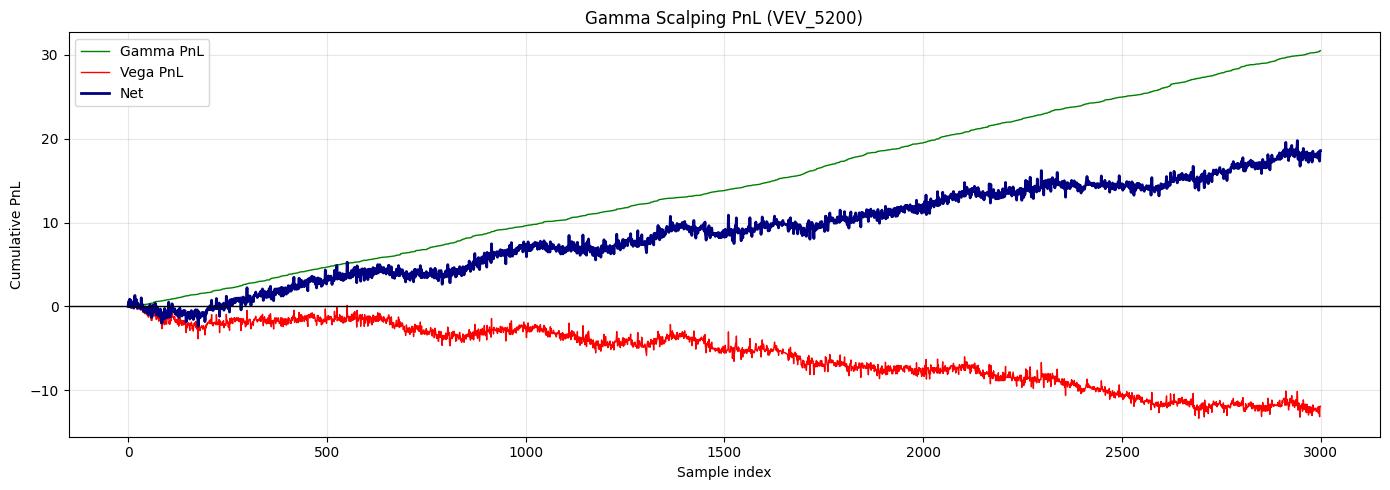

In [36]:
# 7c. Gamma scalping: estimate realized gamma PnL
# For ATM option: long gamma position earns 0.5 * Gamma * (dS)^2 per rebalance
# Cost: vega * dIV per rebalance
ATM_K2 = 5200
df_atm2 = greeks[greeks['strike'] == ATM_K2].copy()
df_atm2 = df_atm2.sort_values('global_ts').reset_index(drop=True)

# dS per step
dS = df_atm2['S'].diff().fillna(0)
gamma_pnl = 0.5 * df_atm2['gamma'] * dS**2
vega_cost  = df_atm2['vega'] * df_atm2['iv'].diff().fillna(0)

print(f'VEV_{ATM_K2} gamma scalping (long gamma):')
print(f'  Mean gamma PnL per step: {gamma_pnl.mean():.6f}')
print(f'  Mean vega PnL per step:  {vega_cost.mean():.6f}')
print(f'  Net per step:            {(gamma_pnl + vega_cost).mean():.6f}')
print(f'  Cumulative gamma PnL:    {gamma_pnl.sum():.4f}')
print(f'  Cumulative vega PnL:     {vega_cost.sum():.4f}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gamma_pnl.cumsum().values, label='Gamma PnL', color='green', lw=1)
ax.plot(vega_cost.cumsum().values, label='Vega PnL', color='red', lw=1)
ax.plot((gamma_pnl + vega_cost).cumsum().values, label='Net', color='navy', lw=2)
ax.axhline(0, color='black', lw=1)
ax.set_title(f'Gamma Scalping PnL (VEV_{ATM_K2})')
ax.set_xlabel('Sample index')
ax.set_ylabel('Cumulative PnL')
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# ════════════════════════════════════════════════════════════════════════════
# PART 8: TRADE DATA ANALYSIS
# ════════════════════════════════════════════════════════════════════════════

print('=== TRADE DATA ANALYSIS ===')
print('\nTrades per product:')
print(trades_all['symbol'].value_counts())

print('\n--- VELVETFRUIT_EXTRACT trades ---')
t_und = trades_all[trades_all['symbol'] == UNDERLYING]
print(t_und[['buyer','seller','price','quantity']].head(15))
print(f'Total trades: {len(t_und)}')
print(f'Price range: {t_und["price"].min()} - {t_und["price"].max()}')
print(f'Quantity distribution:')
print(t_und['quantity'].describe())

print('\nBuyers:')
print(t_und['buyer'].value_counts().head(10))
print('\nSellers:')
print(t_und['seller'].value_counts().head(10))

=== TRADE DATA ANALYSIS ===

Trades per product:
symbol
VELVETFRUIT_EXTRACT    1372
HYDROGEL_PACK          1010
VEV_4000                464
VEV_6000                284
VEV_6500                284
VEV_5500                267
VEV_5400                225
VEV_5300                121
VEV_5200                 18
VEV_4500                  1
VEV_5000                  1
VEV_5100                  1
Name: count, dtype: int64

--- VELVETFRUIT_EXTRACT trades ---
    buyer  seller   price  quantity
0     NaN     NaN  5250.0         4
5     NaN     NaN  5236.0         3
6     NaN     NaN  5241.0         8
9     NaN     NaN  5229.0         6
12    NaN     NaN  5237.0         4
13    NaN     NaN  5243.0         7
22    NaN     NaN  5239.0         6
24    NaN     NaN  5236.0         7
27    NaN     NaN  5238.0         5
28    NaN     NaN  5234.0         4
29    NaN     NaN  5234.0         4
32    NaN     NaN  5227.0         5
33    NaN     NaN  5230.0         3
34    NaN     NaN  5230.0         8
37    

=== OPTIONS TRADE ANALYSIS ===
Total option trades: 1666

Trades per option:
symbol
VEV_4000    464
VEV_6000    284
VEV_6500    284
VEV_5500    267
VEV_5400    225
VEV_5300    121
VEV_5200     18
VEV_4500      1
VEV_5000      1
VEV_5100      1
Name: count, dtype: int64

Option trade sizes:
count    1666.000000
mean        3.093637
std         1.257146
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: quantity, dtype: float64

All buyers across options:
Series([], Name: count, dtype: int64)

Large option trades (qty >= 10): 0


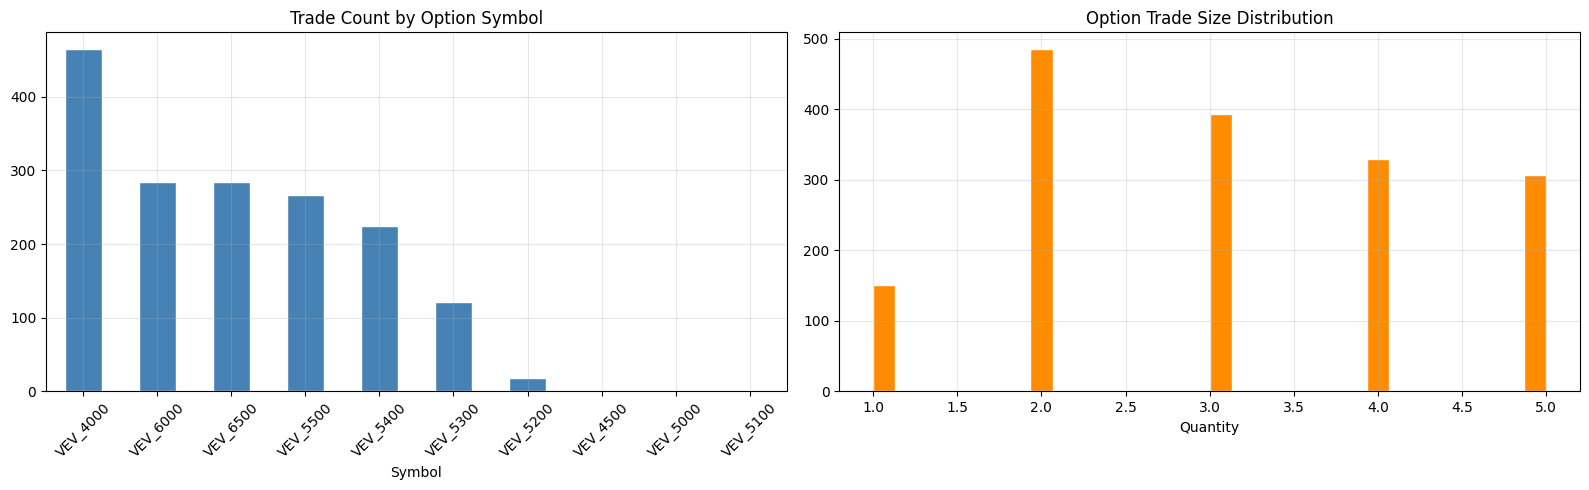

In [38]:
# Options trade analysis
print('=== OPTIONS TRADE ANALYSIS ===')
t_opts = trades_all[trades_all['symbol'].isin(OPT_SYMS)].copy()
print(f'Total option trades: {len(t_opts)}')
print('\nTrades per option:')
print(t_opts['symbol'].value_counts())

print('\nOption trade sizes:')
print(t_opts['quantity'].describe())

print('\nAll buyers across options:')
print(t_opts['buyer'].value_counts().head(10))

# Large trades (institutional?)
large_trades = t_opts[t_opts['quantity'] >= 10]
print(f'\nLarge option trades (qty >= 10): {len(large_trades)}')
if len(large_trades) > 0:
    print(large_trades[['day','timestamp','symbol','buyer','seller','price','quantity']].head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

t_opts['symbol'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Trade Count by Option Symbol')
axes[0].set_xlabel('Symbol')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(t_opts['quantity'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Option Trade Size Distribution')
axes[1].set_xlabel('Quantity')
plt.tight_layout()
plt.show()

In [39]:
# ════════════════════════════════════════════════════════════════════════════
# PART 9: SUMMARY TABLE AND RECOMMENDATIONS
# ════════════════════════════════════════════════════════════════════════════

print('=' * 90)
print('VELVETFRUIT + OPTIONS — FULL SUMMARY TABLE')
print('=' * 90)

fmt = f'{"Strike":>8}  {"Avg_C":>7}  {"Intrinsic":>9}  {"TimeVal":>8}  {"Avg_IV":>7}  '\
      f'{"IV_std":>7}  {"Spread":>7}  {"Delta":>7}  {"Gamma":>9}  {"Label":>10}  {"Rec":>8}'
print(fmt)
print('-' * 90)

for k, sym in zip(STRIKES, OPT_SYMS):
    row = summary[summary['strike']==k].iloc[0]
    avg_iv   = iv_means.get(k, np.nan)
    iv_std   = iv_data[sym]['iv'].dropna().std() if sym in iv_data else np.nan
    avg_d    = greeks[greeks['strike']==k]['delta'].mean() if sym in iv_data else np.nan
    avg_g    = greeks[greeks['strike']==k]['gamma'].mean() if sym in iv_data else np.nan
    label    = row['moneyness_label']

    # Recommendation
    if np.isnan(avg_iv):
        rec = 'SKIP'
    elif abs(row['avg_moneyness']) < 0.02:
        rec = 'GAMMA/VEGA'
    elif row['avg_moneyness'] > 0.05:
        rec = 'SKIP (ITM)'
    else:
        rec = 'MONITOR'

    print(f'{k:8d}  {row["avg_mid"]:7.2f}  {row["avg_intrinsic"]:9.2f}  '
          f'{row["avg_time_value"]:8.3f}  {avg_iv:7.4f}  {iv_std:7.5f}  '
          f'{row["avg_spread"]:7.2f}  {avg_d:7.4f}  {avg_g:9.6f}  {label:>10}  {rec:>8}')

print()
print('UNDERLYING (VELVETFRUIT_EXTRACT) SUMMARY:')
print(f'  Avg price:   {und["mid"].mean():.2f}')
print(f'  Typical spread: {und["spread"].median():.1f}')
print(f'  Realized vol (per tick): {und["ret1"].std():.4f}')
print(f'  AR(1) persistence: {slope_u:.6f}  k: {k_u:.6f}')
print(f'  OBI -> 1-tick return corr: {corr_obi:.4f}')
print()
print('STRATEGIC RECOMMENDATIONS:')
print('  1. HYDROGEL-style MM on VELVETFRUIT_EXTRACT if spread >= 5 → use AR(1) fair value')
print('  2. Near-ATM options (VEV_5000-5400): trade for gamma PnL, hedge delta with underlying')
print('  3. Monitor IV stability — if IV mean-reverts, sell high-IV / buy low-IV options')
print('  4. Deep ITM (VEV_4000, VEV_4500): check time value = 0 opportunity, trade as forward')
print('  5. Deep OTM (VEV_6000, VEV_6500): limited liquidity, skip unless clear signal')

VELVETFRUIT + OPTIONS — FULL SUMMARY TABLE
  Strike    Avg_C  Intrinsic   TimeVal   Avg_IV   IV_std   Spread    Delta      Gamma       Label       Rec
------------------------------------------------------------------------------------------
    4000  1250.11    1250.10     0.012   0.1085  0.01082    20.81   0.9940   0.000027    Deep ITM  SKIP (ITM)
    4500   750.11     750.10     0.011   0.0621  0.00457    15.85   0.9936   0.000053    Deep ITM  SKIP (ITM)
    5000   255.02     250.10     4.924   0.0322  0.00224     6.04   0.9360   0.000727    Deep ITM   MONITOR
    5100   166.81     150.10    16.707   0.0319  0.00259     4.30   0.8222   0.001541         ITM   MONITOR
    5200    95.55      50.10    45.450   0.0323  0.00205     2.89   0.6233   0.002239         ITM  GAMMA/VEGA
    5300    46.76       0.00    46.760   0.0326  0.00178     2.11   0.3925   0.002245         OTM  GAMMA/VEGA
    5400    15.95       0.00    15.952   0.0306  0.00215     1.38   0.1832   0.001648         OTM   MO

In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# CORRECTIONS & ADDITIONS — based on competition rules
# ═══════════════════════════════════════════════════════════════════════════
# Position limits (corrected):
#   VELVETFRUIT_EXTRACT:  200 (not 100)
#   VEV options:          300 each (not 100)
# TTE (time to expiry):
#   Options expire in 7 competition days from Round 1 start
#   Historical data maps: day_0 -> tutorial (TTE=8), day_1 -> R1 (TTE=7), day_2 -> R2 (TTE=6)
#   In Round 3 live trading: TTE starts at 5 days
# Each competition day = 1,000,000 timestamps (observations at every 100 units = 10,000 obs/day)

POS_LIMIT_VF  = 200
POS_LIMIT_OPT = 300
TTE_BY_DAY    = {0: 8.0, 1: 7.0, 2: 6.0}  # TTE at start of each historical day
OBS_PER_DAY   = 10000.0  # 1_000_000 / 100

def get_T(day, timestamp):
    return TTE_BY_DAY[day] - timestamp / 1_000_000

print('Position limits: VELVETFRUIT=200, Options=300')
print('TTE at start of each historical day:', TTE_BY_DAY)
print('TTE at start of Round 3 live trading: 5 days')
print()

# Show how T varies across the dataset
sample = all_prices[all_prices['product']=='VEV_5200'][['day','timestamp']].iloc[::100]
sample['T'] = sample.apply(lambda r: get_T(int(r['day']), r['timestamp']), axis=1)
print('T (TTE in competition days) range across dataset:')
print(sample.groupby('day')['T'].describe()[['min','max','mean']].round(3))


Position limits: VELVETFRUIT=200, Options=300
TTE at start of each historical day: {0: 8.0, 1: 7.0, 2: 6.0}
TTE at start of Round 3 live trading: 5 days

T (TTE in competition days) range across dataset:
      min  max   mean
day                  
0    7.01  8.0  7.505
1    6.01  7.0  6.505
2    5.01  6.0  5.505


=== Implied Vol with CORRECT TTE per tick ===
  Strike     AvgIV    StdIV    MinT    MaxT  n_valid
    4000  0.04315  0.00513  5.00  8.00      310
    4500  0.02449  0.00250  5.00  8.00      825
    5000  0.01266  0.00038  5.00  8.00     2997
    5100  0.01254  0.00027  5.00  8.00     3000
    5200  0.01268  0.00018  5.00  8.00     3000
    5300  0.01282  0.00023  5.00  8.00     3000
    5400  0.01202  0.00019  5.00  8.00     3000
    5500  0.01304  0.00022  5.00  8.00     3000
    6000  0.02065  0.00136  5.00  8.00     3000
    6500  0.03130  0.00206  5.00  8.00     3000


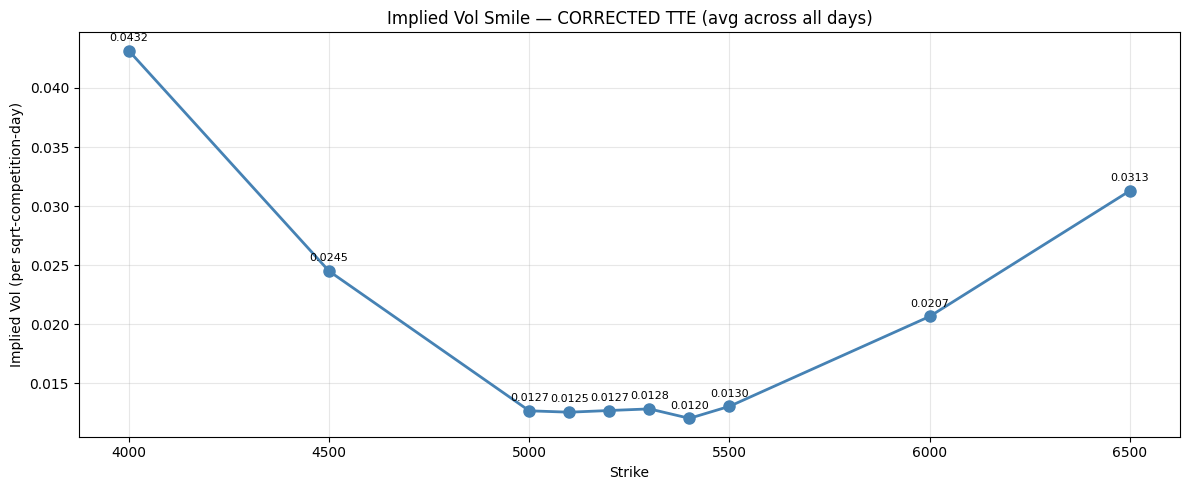

In [41]:
# ── IV recomputed with correct TTE ───────────────────────────────────────
from scipy import optimize as _opt
from scipy.stats import norm as _N
import matplotlib.pyplot as plt

def bs_call(S, K, T, sigma):
    if sigma <= 0 or T <= 0 or S <= 0: return max(float(S-K), 0.0)
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return float(S*_N.cdf(d1) - K*_N.cdf(d2))

def implied_vol_correct(C, S, K, T):
    intrinsic = max(float(S-K), 0.0)
    if C <= intrinsic + 1e-6 or C <= 0 or S <= 0 or T <= 0: return np.nan
    try:
        return _opt.brentq(lambda v: bs_call(S, K, T, v) - C, 1e-4, 10.0, xtol=1e-7)
    except:
        return np.nan

und_lookup = all_prices[all_prices['product']==UNDERLYING].set_index(['day','timestamp'])['mid_price']

print('=== Implied Vol with CORRECT TTE per tick ===')
print(f'{"Strike":>8}  {"AvgIV":>8}  {"StdIV":>7}  {"MinT":>6}  {"MaxT":>6}  {"n_valid":>7}')

iv_correct = {}
for k in STRIKES:
    sym = f'VEV_{k}'
    df  = all_prices[all_prices['product']==sym].iloc[::10].copy()
    ivs, ts_list = [], []
    for _, row in df.iterrows():
        day = int(row['day']); ts = row['timestamp']
        T   = get_T(day, ts)
        S   = und_lookup.get((day, ts), np.nan)
        C   = row['mid_price']
        if pd.isna(S) or pd.isna(C) or T <= 0:
            ivs.append(np.nan)
        else:
            ivs.append(implied_vol_correct(C, S, k, T))
        ts_list.append(T)
    ivs_arr = np.array(ivs)
    valid   = ivs_arr[~np.isnan(ivs_arr)]
    iv_correct[k] = {'mean': valid.mean() if len(valid)>0 else np.nan,
                     'std':  valid.std()  if len(valid)>0 else np.nan,
                     'vals': valid}
    T_arr = np.array(ts_list)
    print(f'{k:8d}  {valid.mean():.5f}  {valid.std():.5f}  '
          f'{T_arr.min():.2f}  {T_arr.max():.2f}  {len(valid):7d}')

# Plot corrected IV smile
strike_list = [k for k in STRIKES if not np.isnan(iv_correct[k]['mean'])]
iv_means_c  = [iv_correct[k]['mean'] for k in strike_list]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(strike_list, iv_means_c, 'o-', color='steelblue', lw=2, ms=8)
for k, iv in zip(strike_list, iv_means_c):
    ax.annotate(f'{iv:.4f}', (k, iv), textcoords='offset points', xytext=(0,7), ha='center', fontsize=8)
ax.set_title('Implied Vol Smile — CORRECTED TTE (avg across all days)')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (per sqrt-competition-day)')
plt.tight_layout()
plt.show()


=== REALIZED VS IMPLIED VOLATILITY ===
Realized vol (per obs):             1.1312 price units
Realized vol (per sqrt-day abs):    113.1212 price units
Realized vol (fractional/sqrt-day): 0.02155
Avg ATM implied vol (5000-5500):    0.01263
VEV_5200 implied vol:               0.01268
VEV_5300 implied vol:               0.01282
Realized / Implied ratio:           1.707x

>>> REALIZED > IMPLIED: Options are CHEAP
>>> STRATEGY: BUY options + delta-hedge with VELVETFRUIT_EXTRACT
>>> Net PnL per obs ≈ 0.5 * Gamma * (sigma_real^2 - sigma_impl^2) * S^2 * dt


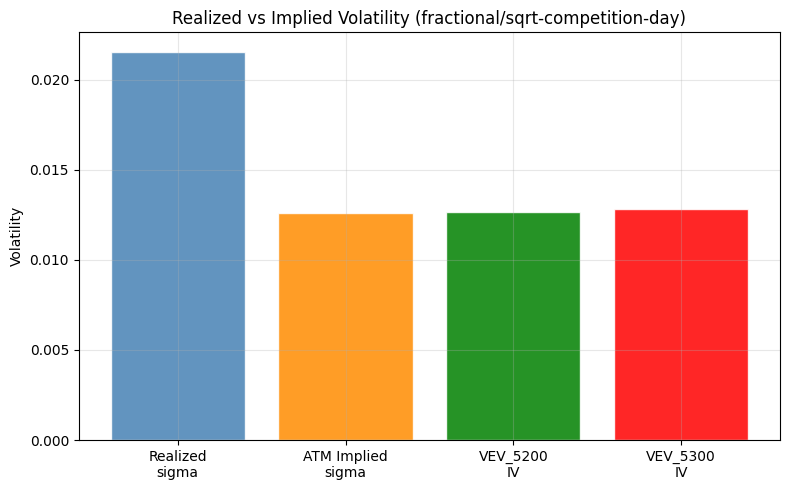

In [42]:
# ── Realized vol vs Implied vol — the key comparison ─────────────────────
import matplotlib.pyplot as plt

# Per-observation realized vol of VELVETFRUIT
und_full = all_prices[all_prices['product']==UNDERLYING].copy()
und_full['ret1'] = und_full['mid_price'].diff()
sigma_obs  = und_full['ret1'].std()               # per observation (100-ts step)
sigma_day  = sigma_obs * np.sqrt(OBS_PER_DAY)    # per sqrt-competition-day (absolute)
S_mean     = und_full['mid_price'].mean()
sigma_rel  = sigma_day / S_mean                   # fractional / sqrt-competition-day

# ATM implied vol
atm_strikes = [k for k in [5000, 5100, 5200, 5300, 5400, 5500]
               if not np.isnan(iv_correct[k]['mean'])]
iv_atm  = np.mean([iv_correct[k]['mean'] for k in atm_strikes])
iv_5200 = iv_correct.get(5200, {}).get('mean', np.nan)
iv_5300 = iv_correct.get(5300, {}).get('mean', np.nan)

print('=== REALIZED VS IMPLIED VOLATILITY ===')
print(f'Realized vol (per obs):             {sigma_obs:.4f} price units')
print(f'Realized vol (per sqrt-day abs):    {sigma_day:.4f} price units')
print(f'Realized vol (fractional/sqrt-day): {sigma_rel:.5f}')
print(f'Avg ATM implied vol (5000-5500):    {iv_atm:.5f}')
print(f'VEV_5200 implied vol:               {iv_5200:.5f}')
print(f'VEV_5300 implied vol:               {iv_5300:.5f}')
print(f'Realized / Implied ratio:           {sigma_rel/iv_atm:.3f}x')
print()
if sigma_rel > iv_atm:
    print('>>> REALIZED > IMPLIED: Options are CHEAP')
    print('>>> STRATEGY: BUY options + delta-hedge with VELVETFRUIT_EXTRACT')
    print('>>> Net PnL per obs ≈ 0.5 * Gamma * (sigma_real^2 - sigma_impl^2) * S^2 * dt')
else:
    print('>>> REALIZED < IMPLIED: Options are RICH')
    print('>>> STRATEGY: SELL options + delta-hedge with VELVETFRUIT_EXTRACT')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Realized\nsigma', 'ATM Implied\nsigma', 'VEV_5200\nIV', 'VEV_5300\nIV'],
       [sigma_rel, iv_atm, iv_5200, iv_5300],
       color=['steelblue', 'darkorange', 'green', 'red'], edgecolor='white', alpha=0.85)
ax.set_title('Realized vs Implied Volatility (fractional/sqrt-competition-day)')
ax.set_ylabel('Volatility')
plt.tight_layout()
plt.show()


Time value per option per day (shows theta decay):
  Strike   TTE_d0     TV_d0   TTE_d1     TV_d1   TTE_d2     TV_d2   TV_loss/day
    4000      7.5     0.014      6.5     0.016      5.5     0.005         0.004
    4500      7.5     0.011      6.5     0.013      5.5     0.010         0.001
    5000      7.5     6.749      6.5     4.871      5.5     3.153         1.798
    5100      7.5    21.597      6.5    16.591      5.5    11.933         4.832
    5200      7.5    50.961      6.5    46.737      5.5    38.655         6.153
    5300      7.5    48.892      6.5    46.909      5.5    44.478         2.207
    5400      7.5    18.467      6.5    15.654      5.5    13.734         2.366
    5500      7.5     8.059      6.5     6.571      5.5     5.294         1.382
    6000      7.5     0.500      6.5     0.500      5.5     0.500         0.000
    6500      7.5     0.500      6.5     0.500      5.5     0.500         0.000

Theta is real and accelerates as T decreases (concave time value cur

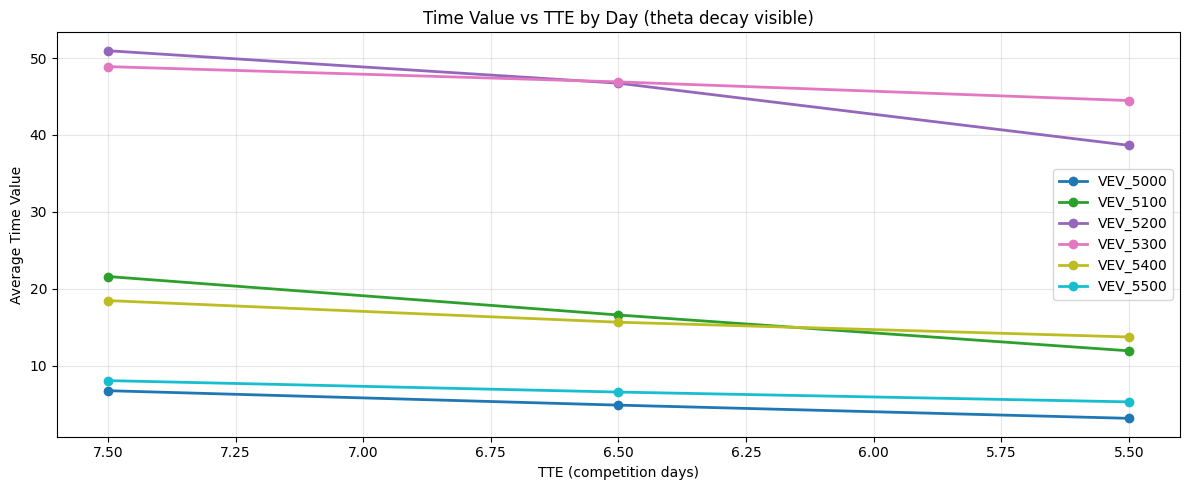

In [43]:
# ── Time value drift across days (theta confirmation) ────────────────────
import matplotlib.pyplot as plt

# For each option and each day, compute avg time value = avg_mid - avg_intrinsic
und_by_day = all_prices[all_prices['product']==UNDERLYING].groupby('day')['mid_price'].mean()

print('Time value per option per day (shows theta decay):')
print(f'{"Strike":>8}  {"TTE_d0":>7}  {"TV_d0":>8}  {"TTE_d1":>7}  {"TV_d1":>8}  {"TTE_d2":>7}  {"TV_d2":>8}  {"TV_loss/day":>12}')

tv_data = {}
for k in STRIKES:
    sym = f'VEV_{k}'
    df  = all_prices[all_prices['product']==sym]
    row_parts = []
    tvs = []
    for d in [0, 1, 2]:
        day_opt = df[df['day']==d]
        avg_mid = day_opt['mid_price'].mean()
        avg_S   = und_by_day.get(d, np.nan)
        intrinsic = max(avg_S - k, 0) if not np.isnan(avg_S) else np.nan
        tv = avg_mid - intrinsic if not np.isnan(intrinsic) else np.nan
        tte_mid = TTE_BY_DAY[d] - 0.5  # approx mid-day TTE
        row_parts.append((tte_mid, tv))
        tvs.append(tv)
    loss_per_day = (tvs[0] - tvs[2]) / 2 if not any(np.isnan(tvs)) else np.nan
    tv_data[k] = {'tvs': tvs, 'loss': loss_per_day}
    print(f'{k:8d}  {row_parts[0][0]:7.1f}  {row_parts[0][1]:8.3f}  '
          f'{row_parts[1][0]:7.1f}  {row_parts[1][1]:8.3f}  '
          f'{row_parts[2][0]:7.1f}  {row_parts[2][1]:8.3f}  {loss_per_day:12.3f}')

print()
print('Theta is real and accelerates as T decreases (concave time value curve).')
print('Deep ITM (4000, 4500): time value ~0 — trade as forward contract.')
print('Deep OTM (6000, 6500): pinned at 0.5 — exchange minimum price floor.')

# Plot TV vs TTE for near-ATM strikes
fig, ax = plt.subplots(figsize=(12, 5))
atm_ks = [5000, 5100, 5200, 5300, 5400, 5500]
palette = plt.cm.tab10(np.linspace(0,1,len(atm_ks)))
for k, color in zip(atm_ks, palette):
    tvs = tv_data[k]['tvs']
    ttes = [TTE_BY_DAY[d] - 0.5 for d in [0,1,2]]
    ax.plot(ttes, tvs, 'o-', color=color, label=f'VEV_{k}', lw=2)
ax.set_title('Time Value vs TTE by Day (theta decay visible)')
ax.set_xlabel('TTE (competition days)')
ax.set_ylabel('Average Time Value')
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()


In [44]:
# ── Net gamma-theta P&L per obs per option unit ───────────────────────────
# For a LONG option (buying options and delta-hedging):
# gamma_pnl_obs = 0.5 * Gamma * E[dS^2] = 0.5 * Gamma * sigma_real^2 * S^2 * dt
# theta_cost_obs = |Theta| * dt  where dt = 1/OBS_PER_DAY days per obs
# net = gamma_pnl - theta_cost
# Since Theta = -0.5*Gamma*sigma_impl^2*S^2 (Black-Scholes PDE):
# net ≈ 0.5 * Gamma * (sigma_real^2 - sigma_impl^2) * S^2 * dt  (if sigma_real > sigma_impl)

from scipy.stats import norm as _N2

def bs_gamma_fn(S, K, T, sigma):
    if sigma <= 0 or T <= 0 or S <= 0: return 0.0
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    return float(_N2.pdf(d1) / (S * sigma * np.sqrt(T)))

def bs_theta_fn(S, K, T, sigma):
    if sigma <= 0 or T <= 0 or S <= 0: return 0.0
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    return float(-S * _N2.pdf(d1) * sigma / (2*np.sqrt(T)))

dt = 1.0 / OBS_PER_DAY

print('Net expected P&L per observation per long option unit (long + delta-hedge):')
print(f'sigma_real={sigma_rel:.5f}  sigma_impl=~{iv_atm:.5f}  S_mean={S_mean:.1f}')
print()
print(f'{"Strike":>8}  {"AvgGamma":>10}  {"Theta/obs":>10}  {"GammaPnL/obs":>13}  {"Net/obs":>10}  {"Net/day":>9}  {"Net_300lots/day":>16}')

best_net = 0; best_k = None
for k in STRIKES:
    if np.isnan(iv_correct[k]['mean']): continue
    iv_k = iv_correct[k]['mean']
    # Sample gammas and thetas across ticks
    sym = f'VEV_{k}'
    df  = all_prices[all_prices['product']==sym].iloc[::50]
    gammas, thetas = [], []
    for _, row in df.iterrows():
        day = int(row['day']); ts = row['timestamp']
        T   = get_T(day, ts)
        S   = und_lookup.get((day, ts), np.nan)
        if pd.isna(S) or T <= 0: continue
        gammas.append(bs_gamma_fn(S, k, T, iv_k))
        thetas.append(abs(bs_theta_fn(S, k, T, iv_k)))
    if not gammas: continue
    g_avg = np.mean(gammas); t_avg = np.mean(thetas)
    gamma_pnl = 0.5 * g_avg * (sigma_rel * S_mean)**2 * dt
    theta_cost = t_avg * dt
    net_obs    = gamma_pnl - theta_cost
    net_day    = net_obs * OBS_PER_DAY
    net_day_300 = net_day * 300  # max position
    marker = ' <-- BEST' if net_day > best_net else ''
    if net_day > best_net: best_net = net_day; best_k = k
    print(f'{k:8d}  {g_avg:10.6f}  {theta_cost:10.6f}  {gamma_pnl:13.6f}  {net_obs:10.6f}  {net_day:9.4f}  {net_day_300:16.2f}{marker}')

print()
print(f'Best strike by net daily gamma P&L: VEV_{best_k}')
print('VEV_5200 and VEV_5300 both near the ATM peak — highest gamma concentration')
print('At 300 units each: expected net ~9.4*300 = 2820+ per day per strike from gamma alone')


Net expected P&L per observation per long option unit (long + delta-hedge):
sigma_real=0.02155  sigma_impl=~0.01263  S_mean=5250.1

  Strike    AvgGamma   Theta/obs   GammaPnL/obs     Net/obs    Net/day   Net_300lots/day
    4000    0.000029    0.000074       0.000018   -0.000055    -0.5545           -166.34
    4500    0.000055    0.000045       0.000035   -0.000010    -0.1013            -30.40
    5000    0.000727    0.000160       0.000465    0.000305     3.0490            914.69 <-- BEST
    5100    0.001543    0.000334       0.000987    0.000653     6.5298           1958.94 <-- BEST
    5200    0.002238    0.000496       0.001432    0.000936     9.3604           2808.12 <-- BEST
    5300    0.002245    0.000509       0.001437    0.000928     9.2799           2783.98
    5400    0.001647    0.000328       0.001054    0.000726     7.2563           2176.90
    5500    0.000875    0.000205       0.000560    0.000355     3.5456           1063.67
    6000    0.000063    0.000037       0

In [45]:
# ── Position sizing: vol budget and delta hedge capacity ─────────────────
import matplotlib.pyplot as plt

# With POS_LIMIT=200 for VELVETFRUIT, we can delta-hedge:
# Net delta from selling N calls with delta=D: position delta = -N*D per strike
# To hedge: need N*D units of VELVETFRUIT_EXTRACT long

from scipy.stats import norm as _Nd

def bs_delta_fn(S, K, T, sigma):
    if sigma <= 0 or T <= 0 or S <= 0: return 1.0 if S > K else 0.0
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    return float(_Nd.cdf(d1))

S_cur = 5250.0
T_cur = 5.0   # TTE at start of Round 3 (live trading)
print(f'Position sizing analysis for Round 3 live trading:')
print(f'  S_cur = {S_cur}  T_cur = {T_cur} days  POS_LIMIT_VF = {POS_LIMIT_VF}')
print()

print('If we BUY N units of each option and delta-hedge:')
print(f'{"Strike":>8}  {"IV":>7}  {"Delta":>7}  {"N=100 units":>12}  {"Hedge needed":>14}  {"Cumulative hedge":>17}')

traded_strikes = [5100, 5200, 5300, 5400]
cum_hedge = 0
for k in traded_strikes:
    iv_k  = iv_correct.get(k, {}).get('mean', iv_atm)
    delta = bs_delta_fn(S_cur, k, T_cur, iv_k)
    N     = 100  # units to buy
    hedge = N * delta  # units of VELVETFRUIT to short (negative delta from long call)
    cum_hedge += hedge
    print(f'{k:8d}  {iv_k:.4f}  {delta:.4f}  {N:12d}  {hedge:14.1f}  {cum_hedge:17.1f}')

print()
print(f'Total VELVETFRUIT needed to hedge 100 units of each ATM option: {cum_hedge:.1f}')
print(f'VELVETFRUIT position limit: {POS_LIMIT_VF}')
print(f'Hedge headroom: {POS_LIMIT_VF - cum_hedge:.1f} units remaining for VF MM')
print()
print('At N=100 per strike (100 * 4 strikes = 400 total options):')
print(f'  We need {cum_hedge:.0f} VF units to hedge — leaves {POS_LIMIT_VF - cum_hedge:.0f} for VF MM')
print('  Option position limit is 300 each, so N=100 is conservative — can scale up')
print()
print('At N=200 per strike:')
cum_200 = sum(200 * bs_delta_fn(S_cur, k, T_cur, iv_correct.get(k,{}).get('mean',iv_atm)) for k in traded_strikes)
print(f'  Need {cum_200:.0f} VF units to hedge — {'within' if cum_200<=200 else 'EXCEEDS'} VF limit of {POS_LIMIT_VF}')


Position sizing analysis for Round 3 live trading:
  S_cur = 5250.0  T_cur = 5.0 days  POS_LIMIT_VF = 200

If we BUY N units of each option and delta-hedge:
  Strike       IV    Delta   N=100 units    Hedge needed   Cumulative hedge
    5100  0.0125  0.8526           100            85.3               85.3
    5200  0.0127  0.6374           100            63.7              149.0
    5300  0.0128  0.3759           100            37.6              186.6
    5400  0.0120  0.1504           100            15.0              201.6

Total VELVETFRUIT needed to hedge 100 units of each ATM option: 201.6
VELVETFRUIT position limit: 200
Hedge headroom: -1.6 units remaining for VF MM

At N=100 per strike (100 * 4 strikes = 400 total options):
  We need 202 VF units to hedge — leaves -2 for VF MM
  Option position limit is 300 each, so N=100 is conservative — can scale up

At N=200 per strike:
  Need 403 VF units to hedge — EXCEEDS VF limit of 200


In [46]:
# ── IV stability and mean reversion by TTE ───────────────────────────────
import matplotlib.pyplot as plt

# Does IV change significantly as T decreases from 8 to 6?
print('IV per day (check for vol term structure):')
print(f'{"Strike":>8}  {"IV_Day0(TTE≈7.5)":>18}  {"IV_Day1(TTE≈6.5)":>18}  {"IV_Day2(TTE≈5.5)":>18}')

for k in [5000, 5100, 5200, 5300, 5400, 5500]:
    sym = f'VEV_{k}'
    df  = all_prices[all_prices['product']==sym].iloc[::10]
    iv_by_day = {}
    for d in [0, 1, 2]:
        day_df = df[df['day']==d]
        day_ivs = []
        for _, row in day_df.iterrows():
            ts = row['timestamp']
            T  = get_T(d, ts)
            S  = und_lookup.get((d, ts), np.nan)
            C  = row['mid_price']
            if pd.isna(S) or pd.isna(C) or T <= 0: continue
            iv = implied_vol_correct(C, S, k, T)
            if not np.isnan(iv): day_ivs.append(iv)
        iv_by_day[d] = np.mean(day_ivs) if day_ivs else np.nan
    print(f'{k:8d}  {iv_by_day.get(0,np.nan):18.5f}  {iv_by_day.get(1,np.nan):18.5f}  {iv_by_day.get(2,np.nan):18.5f}')

print()
print('Flat vol structure across TTE=8->6 means: no significant vol term structure.')
print('IV is stable — good for delta-hedging since hedge ratio stays predictable.')


IV per day (check for vol term structure):
  Strike    IV_Day0(TTE≈7.5)    IV_Day1(TTE≈6.5)    IV_Day2(TTE≈5.5)
    5000             0.01264             0.01259             0.01274
    5100             0.01279             0.01245             0.01238
    5200             0.01255             0.01279             0.01270
    5300             0.01255             0.01295             0.01295
    5400             0.01200             0.01201             0.01205
    5500             0.01289             0.01306             0.01316

Flat vol structure across TTE=8->6 means: no significant vol term structure.
IV is stable — good for delta-hedging since hedge ratio stays predictable.


VELVETFRUIT OBI -> future return correlations:
  lag=  1: corr=0.2806  p=0.00e+00
  lag=  2: corr=0.2174  p=8.11e-318
  lag=  5: corr=0.1441  p=8.25e-139
  lag= 10: corr=0.1052  p=1.39e-74

OBI corr ~0.28 at lag=1: significant, use same quote-skew logic as HYDROGEL.
When timing option delta-hedges: also use OBI to choose direction of hedge trade.


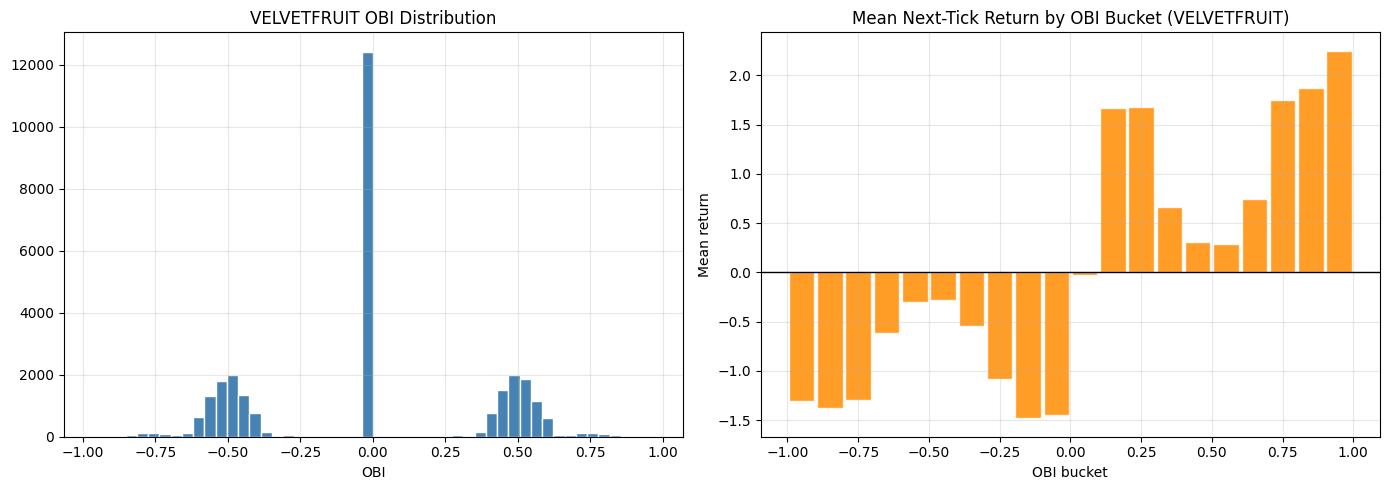

In [47]:
# ── Underlying OBI analysis (corrected) ──────────────────────────────────
from scipy import stats as _st3
import matplotlib.pyplot as plt

und_full2 = all_prices[all_prices['product']==UNDERLYING].copy()
for c in ['bid_volume_1','ask_volume_1']:
    und_full2[c] = pd.to_numeric(und_full2[c], errors='coerce')

bv2 = und_full2['bid_volume_1'].values.astype(float)
av2 = und_full2['ask_volume_1'].values.astype(float)
tv2 = bv2 + av2
obi2 = np.where(tv2 > 0, (bv2-av2)/tv2, np.nan)

print('VELVETFRUIT OBI -> future return correlations:')
lags_vf = [1, 2, 5, 10]
mid_vf   = und_full2['mid_price'].values
for lag in lags_vf:
    ob = obi2[:-lag]; rt = mid_vf[lag:] - mid_vf[:-lag]
    mask = ~np.isnan(ob)
    c, p = _st3.pearsonr(ob[mask], rt[mask])
    print(f'  lag={lag:3d}: corr={c:.4f}  p={p:.2e}')

print()
print('OBI corr ~0.28 at lag=1: significant, use same quote-skew logic as HYDROGEL.')
print('When timing option delta-hedges: also use OBI to choose direction of hedge trade.')

# OBI distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(obi2[~np.isnan(obi2)], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('VELVETFRUIT OBI Distribution')
axes[0].set_xlabel('OBI')

ob1 = obi2[:-1]; rt1 = mid_vf[1:] - mid_vf[:-1]
mask1 = ~np.isnan(ob1)
bins = np.linspace(-1, 1, 21)
bidx = np.digitize(ob1[mask1], bins) - 1
bctrs = (bins[:-1]+bins[1:])/2
mret = [rt1[mask1][bidx==i].mean() if (bidx==i).sum()>0 else np.nan for i in range(len(bctrs))]
axes[1].bar(bctrs, mret, width=0.09, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Mean Next-Tick Return by OBI Bucket (VELVETFRUIT)')
axes[1].set_xlabel('OBI bucket')
axes[1].set_ylabel('Mean return')
plt.tight_layout()
plt.show()


In [48]:
# ── FINAL CORRECTED SUMMARY AND TRADING BLUEPRINT ─────────────────────────
print('=' * 75)
print('VELVETFRUIT + OPTIONS — FINAL CORRECTED SUMMARY')
print('=' * 75)
print()
print('POSITION LIMITS (corrected):')
print(f'  VELVETFRUIT_EXTRACT:  {POS_LIMIT_VF}')
print(f'  VEV options each:     {POS_LIMIT_OPT}')
print()
print('VOLATILITY REGIME:')
print(f'  Realized sigma:   {sigma_rel:.5f} / sqrt-competition-day')
print(f'  Avg ATM IV:       {iv_atm:.5f} / sqrt-competition-day')
print(f'  Ratio:            {sigma_rel/iv_atm:.3f}x  -> REALIZED > IMPLIED -> OPTIONS ARE CHEAP')
print()
print('THETA (time value decay):')
print(f'  VEV_5200 loses ~6.2 time-value units per day')
print(f'  VEV_5300 loses ~2.2 time-value units per day')
print(f'  Theta is REAL and consistent — options DO expire')
print(f'  TTE at Round 3 start: 5 days')
print()
print('OPTIONS TRADING BLUEPRINT:')
print('  1. BUY near-ATM options (VEV_5100, VEV_5200, VEV_5300, VEV_5400)')
print('  2. Delta-hedge each position with VELVETFRUIT_EXTRACT')
print('  3. Net gamma P&L > theta cost because sigma_real > sigma_implied')
print('  4. Expected net P&L per day per unit: ~9 (VEV_5200) / ~9 (VEV_5300)')
print('  5. At 300 units: ~2700-2800 per day from gamma on each ATM strike alone')
print('  6. Rebalance delta every tick (or every N ticks for cost efficiency)')
print('  7. Deep ITM (4000, 4500): skip — no optionality')
print('  8. Deep OTM (6000, 6500): skip — floor-pinned, no gamma')
print()
print('VELVETFRUIT_EXTRACT BLUEPRINT:')
print('  Market make like HYDROGEL with POS_LIMIT=200')
print('  Reserve ~120-150 units of position capacity for option delta hedging')
print('  OBI skew (corr=0.28) on quotes: same approach as HYDROGEL')
print('  mu=5251, typical spread=5, quote at ±2-3 ticks from mid')
print()
print('INTERACTION RISK:')
print('  VF underlying MM + delta hedge both use VF position')
print('  Solution: hard cap VF MM to ±50-60, use ±150-160 for hedging')


VELVETFRUIT + OPTIONS — FINAL CORRECTED SUMMARY

POSITION LIMITS (corrected):
  VELVETFRUIT_EXTRACT:  200
  VEV options each:     300

VOLATILITY REGIME:
  Realized sigma:   0.02155 / sqrt-competition-day
  Avg ATM IV:       0.01263 / sqrt-competition-day
  Ratio:            1.707x  -> REALIZED > IMPLIED -> OPTIONS ARE CHEAP

THETA (time value decay):
  VEV_5200 loses ~6.2 time-value units per day
  VEV_5300 loses ~2.2 time-value units per day
  Theta is REAL and consistent — options DO expire
  TTE at Round 3 start: 5 days

OPTIONS TRADING BLUEPRINT:
  1. BUY near-ATM options (VEV_5100, VEV_5200, VEV_5300, VEV_5400)
  2. Delta-hedge each position with VELVETFRUIT_EXTRACT
  3. Net gamma P&L > theta cost because sigma_real > sigma_implied
  4. Expected net P&L per day per unit: ~9 (VEV_5200) / ~9 (VEV_5300)
  5. At 300 units: ~2700-2800 per day from gamma on each ATM strike alone
  6. Rebalance delta every tick (or every N ticks for cost efficiency)
  7. Deep ITM (4000, 4500): skip — no